# Stochastic Optimization Scheduler Comparison

Single notebook orchestrating all experiment versions (V0–V5).

**Objective**: Compare learning rate schedulers (None, Exponential Decay, Cosine Annealing, Cyclic LR, One-Cycle) across optimizers (SGD, Adam) on convex (logistic regression) and non-convex (MLP on MNIST) problems.

**Metrics**: Convergence speed (EtT), Area Under Loss (AUL), empirical convergence rate (ρ̂), stability (RV/CV, SI), Robbins-Monro compliance.

## 1. Imports

In [21]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import time
from pathlib import Path
import pickle

import pandas as pd
import torch

from stoc_opt_scheduler_comparison.config import load_config
from stoc_opt_scheduler_comparison.data_load import get_dataloaders
from stoc_opt_scheduler_comparison.models import create_model
from stoc_opt_scheduler_comparison.training import get_optimizer, get_scheduler, train_loop, get_dynamic_scheduler_params
from stoc_opt_scheduler_comparison.tracking import MLflowLogger, load_results_from_mlflow
from stoc_opt_scheduler_comparison.training.lstar import (
    compute_convex_L_star,
    compute_empirical_L_star,
)
from stoc_opt_scheduler_comparison.evaluation import (
    TrainingHistory,
    compute_convergence_metrics,
    aggregate_metrics,
    compute_L_star_global,
    compute_global_initial_loss,
    compute_all_e_target_levels,
    compute_aggregated_config_metrics,
    build_convergence_dataframe,
    E_TARGET_LEVELS,
)
from stoc_opt_scheduler_comparison.visualization.plots import plot_all, plot_convergence_boxplot

print(f"PyTorch {torch.__version__} | Device CUDA: {torch.cuda.is_available()}")

PyTorch 2.11.0+cu130 | Device CUDA: True


## 2. Configuration

In [2]:
config = load_config("../configs/experiment_config.yaml")

print(f"Experiment: {config.experiment_name}")
print(f"Seeds: {config.seeds}")
print(f"Schedulers: {config.schedulers}")
print(f"Optimizers: {config.optimizers}")
print(f"Epochs: {config.epochs}, LR: {config.lr}, Batch: {config.batch_size}")
print(f"Experiments: {config.experiments}")

Experiment: scheduler_comparison_v4
Seeds: (6, 22, 84, 165, 405, 440, 492, 561, 910, 947)
Schedulers: ('none', 'cosine', 'exponential', 'cyclic', 'one-cycle')
Optimizers: ('sgd', 'adam')
Epochs: 100, LR: {'sgd': 0.01, 'adam': 0.001}, Batch: 128
Experiments: {'convex': ExperimentDef(model='logistic', dataset='breast_cancer', batch_size=128, epochs=100), 'non-convex': ExperimentDef(model='mlp', dataset='mnist', batch_size=128, epochs=100)}


In [3]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Output directories
figures_dir = Path("../reports/figures")
figures_dir.mkdir(parents=True, exist_ok=True)
print(f"Figures saved to: {figures_dir.absolute()}")

results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Results saved to: {results_dir.absolute()}")

Using device: cuda
Figures saved to: /home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/notebooks/../reports/figures
Results saved to: /home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/notebooks/../results


## 3. Experiment Matrix

Each experiment is defined by: `(problem_type, scheduler, optimizer, seed)`.

The config specifies which model and dataset to use for each problem type.

In [4]:
def build_experiment_matrix(config):
    """Build list of (problem_type, scheduler, optimizer, seed) tuples."""
    matrix = []
    for problem_type, exp_def in config.experiments.items():
        for scheduler in config.schedulers:
            for optimizer in config.optimizers:
                for seed in config.seeds:
                    matrix.append((problem_type, exp_def, scheduler, optimizer, seed))
    return matrix

experiment_matrix = build_experiment_matrix(config)
print(f"Total experiments: {len(experiment_matrix)}")
print(f"  Convex: {len([e for e in experiment_matrix if e[0] == 'convex'])}")
print(f"  Non-convex: {len([e for e in experiment_matrix if e[0] == 'non-convex'])}")

Total experiments: 200
  Convex: 100
  Non-convex: 100


## 4. Run All Experiments

For each configuration:
1. Load data (with seed for reproducibility)
2. Create model
3. Create optimizer + scheduler
4. Train and collect history
5. Log to MLflow

In [ ]:
def run_single_experiment(problem_type, exp_def, scheduler_name, optimizer_name, seed, config, mlflow_logger):
    """Run one experiment configuration and return (run_name, history, test_metrics)."""
    run_name = f"{problem_type}_{scheduler_name}_{optimizer_name}_{seed}"

    # Per-experiment epoch count (falls back to global config)
    epochs = exp_def.epochs or config.epochs


    # batch_size per-experiment overrides global config
    batch_size = exp_def.batch_size
    
    # Load data
    dataloaders = get_dataloaders(
        dataset_name=exp_def.dataset,
        batch_size=batch_size,
        seed=seed,
        test_size=config.test_size,
    )
    
    # Create model
    model = create_model(
        name=exp_def.model,
        input_dim=dataloaders["n_features"],
        output_dim=dataloaders["n_classes"],
    )
    
    # Create optimizer + scheduler
    lr = config.lr.get(optimizer_name, 0.001) if isinstance(config.lr, dict) else config.lr
    optimizer = get_optimizer(model, name=optimizer_name, lr=lr)
    sched_params = config.scheduler_params.get(scheduler_name, {})

    # 2. Ottieni la lunghezza del dataloader (steps per epoch)
    steps = len(dataloaders["train"])

    # 3. Richiami la funzione
    sched_params = get_dynamic_scheduler_params(
        scheduler_name=scheduler_name,
        lr=lr,
        epochs=epochs,
        steps_per_epoch=steps,
        base_sched_params=sched_params
    )

    # 4. Inizializzi lo scheduler (pseudo-codice in base a come lo chiami)
    scheduler = get_scheduler(optimizer, name=scheduler_name, **sched_params)
    
    # Train
    history = train_loop(
        model=model,
        train_loader=dataloaders["train"],
        test_loader=dataloaders["test"],
        optimizer=optimizer,
        scheduler=scheduler,
        scheduler_name=scheduler_name,
        epochs=epochs,
        device=device,
        verbose=epochs,  # Suppress per-epoch output during batch runs
    )
    
    # Log to MLflow
    with mlflow_logger.child_run(run_name):
        mlflow_logger.log_params({
            "problem_type": problem_type,
            "model": exp_def.model,
            "dataset": exp_def.dataset,
            "optimizer": optimizer_name,
            "scheduler": scheduler_name,
            "seed": seed,
            "lr": config.lr,
            "epochs": epochs,
            "batch_size": batch_size,
        })
        mlflow_logger.log_history(history)
    
    # Convert lists to numpy arrays for efficient post-processing
    history.to_arrays()

    return run_name, history


def run_all_experiments(config, experiment_matrix):
    """Run all experiments and collect results."""
    results = {"convex": {}, "non-convex": {}}
    mlflow_logger = MLflowLogger(config.experiment_name, tracking_uri="../mlruns")
    
    total = len(experiment_matrix)
    start_time = time.time()
    
    for i, (problem_type, exp_def, scheduler, optimizer, seed) in enumerate(experiment_matrix, 1):
        run_name, history = run_single_experiment(
            problem_type, exp_def, scheduler, optimizer, seed, config, mlflow_logger
        )
        
        results[problem_type][run_name] = history
        
        elapsed = time.time() - start_time
        eta = elapsed / i * (total - i) if i > 0 else 0
        print(f"[{i}/{total}] {run_name}: test_acc={history.test_metrics.get('accuracy', 0):.4f} | ETA: {eta/60:.1f}min")
    
    total_time = time.time() - start_time
    print(f"\nAll experiments complete in {total_time/60:.1f} minutes")
    return results

In [ ]:
# Execute all experiments
results = run_all_experiments(config, experiment_matrix)

/home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/.venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


  Epoch 50/50: loss=0.1912, acc=0.9253, lr=0.010000
[1/100] convex_none_sgd_6: test_acc=0.9386 | ETA: 0.4min
  Epoch 50/50: loss=0.1636, acc=0.9407, lr=0.010000
[2/100] convex_none_sgd_22: test_acc=0.8596 | ETA: 0.3min
  Epoch 50/50: loss=0.1596, acc=0.9495, lr=0.010000
[3/100] convex_none_sgd_84: test_acc=0.9386 | ETA: 0.3min
  Epoch 50/50: loss=0.1481, acc=0.9692, lr=0.010000
[4/100] convex_none_sgd_165: test_acc=0.9649 | ETA: 0.3min
  Epoch 50/50: loss=0.1437, acc=0.9538, lr=0.010000
[5/100] convex_none_sgd_405: test_acc=0.9561 | ETA: 0.3min
  Epoch 50/50: loss=0.1417, acc=0.9560, lr=0.010000
[6/100] convex_none_sgd_440: test_acc=0.9123 | ETA: 0.3min
  Epoch 50/50: loss=0.1370, acc=0.9758, lr=0.010000
[7/100] convex_none_sgd_492: test_acc=0.9561 | ETA: 0.3min
  Epoch 50/50: loss=0.1490, acc=0.9648, lr=0.010000
[8/100] convex_none_sgd_561: test_acc=0.9825 | ETA: 0.3min
  Epoch 50/50: loss=0.1573, acc=0.9670, lr=0.010000
[9/100] convex_none_sgd_910: test_acc=0.9386 | ETA: 0.3min
  Epo

## 5. Aggregate Results & Convergence Metrics

Aggregate each run results on seed level.

Compute six convergence metrics for each run:
- **EtT**: Epochs to Threshold
- **AUL**: Area Under Loss curve
- **ρ̂**: Empirical convergence rate
- **RV/CV**: Rolling Variance / Coefficient of Variation
- **SI**: Smoothness Index
- **Robbins-Monro**: LR schedule compliance

In [6]:
# # ── Compute optimal loss (L*) for each problem type ──
# L_star_values = {}
# L0_values = {}

# # Convex L*: use L-BFGS to find analytical global minimum
# print("Computing convex L* via L-BFGS...")
# L_star_convex = compute_convex_L_star(test_size=config.test_size, tollerance=1e-3, max_iter=100, seed=42)
# print(f"  Convex L* (L-BFGS) = {L_star_convex:.14f}")

# L0_convex = compute_global_initial_loss(results["convex"])

In [ ]:
print("\nComputing convex L* via extended training...")
exp_def_c = config.experiments["convex"]
L_star_convex = compute_empirical_L_star(
    results_by_problem=results["convex"],
    exp_def=exp_def_c,
    scheduler_params=config.scheduler_params,
    lr_config=config.lr,
    device=device,
    extended_epochs=150,
    seed=42,
    use_lr_decay=False,  # <-- NUOVO PARAMETRO BOOLEANO --- IGNORE ---
)
print(f"  Convex L* (extended) = {L_star_convex:.10f}") 


Computing convex L* via extended training...
Best config for extended run: sgd + one-cycle
Extended run complete (150 epochs). L* = 0.044639
  Convex L* (extended) = 0.0446394829


In [ ]:
# Non-convex L*: extended training run from best config
print("\nComputing non-convex L* via extended training...")
exp_def_nc = config.experiments["non-convex"]
L_star_nonconvex = compute_empirical_L_star(
    results_by_problem=results["non-convex"],
    exp_def=exp_def_nc,
    scheduler_params=config.scheduler_params,
    lr_config=config.lr,
    device=device,
    extended_epochs=200,
    seed=42,
    use_lr_decay=False,
)
print(f"  Non-convex L* (extended) = {L_star_nonconvex:.10f}") 


Computing non-convex L* via extended training...
Best config for extended run: adam + cosine
Extended run complete (200 epochs). L* = 0.001733
  Non-convex L* (extended) = 0.0017325752


In [9]:

# Global initial loss (L0) for E_target computation
L0_convex = compute_global_initial_loss(results["convex"])
L0_nonconvex = compute_global_initial_loss(results["non-convex"])
print(f"\n--- Global Initial Loss (L0) ---")
print(f"  Convex L0 = {L0_convex:.6f}")
print(f"  Non-convex L0 = {L0_nonconvex:.6f}")


--- Global Initial Loss (L0) ---
  Convex L0 = 0.939544
  Non-convex L0 = 0.610164


In [10]:
# ── Compute convergence metrics with proper L* values ──
convergence_results = {}
L_star_map = {"convex": L_star_convex, "non-convex": L_star_nonconvex}
L0_map = {"convex": L0_convex, "non-convex": L0_nonconvex}

for problem_type in ["convex", "non-convex"]:
    results_by_problem = results[problem_type]
    L_star_global = L_star_map[problem_type]
    L0_global = L0_map[problem_type]

    metrics_dict = compute_convergence_metrics(results, problem_type, L_star=L_star_global)
    aggregated = aggregate_metrics(metrics_dict)
    max_epochs = config.experiments[problem_type].epochs or config.epochs
    convergence_results[problem_type] = {
        "per_run": metrics_dict,
        "aggregated": aggregated,
        "L_star": L_star_global,
        "L0": L0_global,
        "max_epochs": max_epochs,
    }
    print(f"\n=== {problem_type.upper()} ===")
    print(f"Runs analyzed: {len(metrics_dict)}")
    print(f"Configurations: {list(aggregated.keys())}")
    print(f"L* = {L_star_global:.10f}, L0 = {L0_global:.6f}")


=== CONVEX ===
Runs analyzed: 100
Configurations: ['sgd_none', 'adam_none', 'sgd_cosine', 'adam_cosine', 'sgd_exponential', 'adam_exponential', 'sgd_cyclic', 'adam_cyclic', 'sgd_one-cycle', 'adam_one-cycle']
L* = 0.0446394829, L0 = 0.939544

=== NON-CONVEX ===
Runs analyzed: 100
Configurations: ['sgd_none', 'adam_none', 'sgd_cosine', 'adam_cosine', 'sgd_exponential', 'adam_exponential', 'sgd_cyclic', 'adam_cyclic', 'sgd_one-cycle', 'adam_one-cycle']
L* = 0.0017325752, L0 = 0.610164


## 5b. E_target (Sub-optimality Gap) Analysis

Compute epochs-to-target for multiple tolerance levels (E_target levels).
Each level defines a convergence threshold: L_target = L* + ε·(L0 − L*).

In [11]:
e_target_results = {}

for problem_type in ["convex", "non-convex"]:
    L_star = convergence_results[problem_type]["L_star"]
    results_by_problem = results[problem_type]
    max_epochs = config.experiments[problem_type].epochs or config.epochs
    levels = E_TARGET_LEVELS    

    df_dict = compute_all_e_target_levels(
        results_by_problem, problem_type, L_star, max_epochs, levels,
    )
    e_target_results[problem_type] = df_dict

    print(f"\n=== {problem_type.upper()} - E_target Analysis === ")
    for level_name, df in df_dict.items():
        n_converged = (df["Epochs_to_Target"] < max_epochs).sum()
        n_total = len(df)
        print(f"  {level_name}: {n_converged}/{n_total} converged ")
        if not df.empty:
            print(f"L_target = {df['L_target'].iloc[0]:.6f}")



=== CONVEX - E_target Analysis === 
  E_target_lv1: 31/100 converged 
L_target = 0.089385
  E_target_lv2: 24/100 converged 
L_target = 0.067012
  E_target_lv3: 10/100 converged 
L_target = 0.053589

=== NON-CONVEX - E_target Analysis === 
  E_target_lv1: 60/100 converged 
L_target = 0.032154
  E_target_lv2: 44/100 converged 
L_target = 0.016943
  E_target_lv3: 30/100 converged 
L_target = 0.007817


In [27]:
# Display aggregated metrics as DataFrame
for problem_type in ["convex", "non-convex"]:
    agg = convergence_results[problem_type]["aggregated"]
    df = pd.DataFrame.from_dict(agg, orient="index")
    
    # Select key columns for display
    display_cols = [
        "optimizer", "scheduler", "n_runs",
        "EtT_mean", "EtT_std",
        "AUL_mean", "AUL_std",
        "rho_hat_mean", "rho_hat_std",
        "CV_final_mean", "CV_final_std",
        "SI_mean", "SI_std",
        "final_test_accuracy_mean", "final_test_accuracy_std",
    ]
    available_cols = [c for c in display_cols if c in df.columns]
    
    print(f"\n{'='*60}")
    print(f"{problem_type.upper()} - Aggregated Metrics")
    print(f"{'='*60}")
    display(df[available_cols].round(4))


CONVEX - Aggregated Metrics


,optimizer,scheduler,n_runs,EtT_mean,EtT_std,AUL_mean,AUL_std,rho_hat_mean,rho_hat_std,CV_final_mean,CV_final_std,SI_mean,SI_std
sgd_none,sgd,none,10,45.1667,22.7627,19.7961,2.5106,0.9922,0.0010,0.0109,0.0015,0.0094,0.0051
adam_none,adam,none,10,72.1429,9.7604,31.7560,12.4952,0.9877,0.0013,0.0188,0.0033,0.0111,0.0060
sgd_cosine,sgd,cosine,10,44.0000,0.0000,18.9324,2.4707,0.9981,0.0002,0.0002,0.0000,0.0053,0.0031
adam_cosine,adam,cosine,10,NaN,NaN,27.4582,14.6855,0.9969,0.0005,0.0004,0.0001,0.0071,0.0053
sgd_exponential,sgd,exponential,10,41.0000,0.0000,23.7678,3.5788,0.9969,0.0005,0.0038,0.0007,0.0083,0.0041
adam_exponential,adam,exponential,10,NaN,NaN,32.2112,6.4399,0.9952,0.0004,0.0066,0.0007,0.0072,0.0022
sgd_cyclic,sgd,cyclic,10,6.1000,6.4257,6.8910,0.8953,0.9921,0.0065,0.0035,0.0009,0.0071,0.0042
adam_cyclic,adam,cyclic,10,47.5000,19.0013,15.9357,3.7440,0.9903,0.0014,0.0124,0.0027,0.0091,0.0036
sgd_one-cycle,sgd,one-cycle,10,7.4000,2.0100,7.3264,0.7627,0.9927,0.0011,0.0004,0.0001,0.0082,0.0037
adam_one-cycle,adam,one-cycle,10,23.8000,2.5612,18.1703,4.6483,0.9944,0.0015,0.0004,0.0001,0.0098,0.0034



NON-CONVEX - Aggregated Metrics


,optimizer,scheduler,n_runs,EtT_mean,EtT_std,AUL_mean,AUL_std,rho_hat_mean,rho_hat_std,CV_final_mean,CV_final_std,SI_mean,SI_std
sgd_none,sgd,none,10,48.3,1.4177,12.5319,0.1558,0.9893,0.0002,0.0312,0.0052,0.0095,0.0001
adam_none,adam,none,10,20.2,1.1662,3.7957,0.0476,NaN,NaN,0.0734,0.0168,0.0053,0.0002
sgd_cosine,sgd,cosine,10,64.0,4.4272,13.9837,0.1064,0.9976,0.0000,0.0113,0.0028,0.0094,0.0002
adam_cosine,adam,cosine,10,18.3,1.0050,2.8457,0.0291,0.9651,0.0023,0.0995,0.0161,0.0047,0.0001
sgd_exponential,sgd,exponential,10,NaN,NaN,15.8605,0.2230,0.9968,0.0002,0.0115,0.0033,0.0092,0.0002
adam_exponential,adam,exponential,10,15.2,0.6000,2.5920,0.0265,0.9759,0.0013,0.0986,0.0156,0.0046,0.0001
sgd_cyclic,sgd,cyclic,10,12.1,0.3000,2.8141,0.0547,0.9892,0.0007,0.0579,0.0136,0.0050,0.0001
adam_cyclic,adam,cyclic,10,25.9,2.1190,5.0234,0.1298,NaN,NaN,0.0592,0.0186,0.0068,0.0002
sgd_one-cycle,sgd,one-cycle,10,38.9,1.0440,5.1720,0.0895,0.9505,0.0010,0.1034,0.0112,0.0065,0.0002
adam_one-cycle,adam,one-cycle,10,87.9,1.7578,18.2841,0.3694,0.9662,0.0007,0.0434,0.0100,0.0152,0.0008


## 5c. Aggregated Curve Metrics & Analysis Tables

All convergence metrics (suboptimality_gap, AUL_norm, CV_final, SI_asymptotic, RV) are
computed **on the average loss curve** per configuration (first aggregate runs → mean loss
trajectory, then compute metrics).  E_target at tolerance lv1 (0.05) replaces EtT as the
primary convergence-speed metric on the aggregated curve.

Per-run individual metrics are preserved for boxplots and convergence counting.


In [28]:
# ── Compute aggregated-curve metrics and build three analysis tables ──

for problem_type in ["convex", "non-convex"]:
    cr = convergence_results[problem_type]

    agg_curve_df = compute_aggregated_config_metrics(
        aggregated=cr["aggregated"],
        per_run_metrics=cr["per_run"],
        L_star=cr["L_star"],
        L0=cr["L0"],
        problem_type=problem_type,
        max_epochs=cr["max_epochs"],
        e_target_epsilon=0.05,  # lv1
    )
    convergence_results[problem_type]["aggregated_curve_metrics"] = agg_curve_df

    print(f"\n{'='*60}")
    print(f"{problem_type.upper()} - Aggregated Curve Metrics")
    print(f"{'='*60}")

    if agg_curve_df.empty:
        print("  (no data)")
        continue

    # ─── Table 1: Convergence Analysis ─── 
    convergence_cols = [
        "optimizer", "scheduler", "n_runs", "n_converging_runs",
        "suboptimality_gap", "AUL_norm", "E_target",
    ]
    conv_metrics_cols = ["suboptimality_gap", "E_target", "AUL_norm"]
    conv_df = agg_curve_df[convergence_cols].copy()
    conv_df["convergence_rate"] = conv_df["n_converging_runs"] / conv_df["n_runs"]
    conv_df = conv_df.sort_values(conv_metrics_cols, ascending=True)

    print("\n[ Convergence Analysis ]")
    display(
        conv_df.style
        .background_gradient(subset=conv_metrics_cols, cmap="YlOrRd_r")
        .format({
            "suboptimality_gap": "{:.6f}",
            "AUL_norm": "{:.4f}",
            "E_target": "{:.0f}",
            "convergence_rate": "{:.0%}",
        })
    )

    # ─── Table 2: Stability Analysis ─── 
    stability_cols = [
        "optimizer", "scheduler",
        "CV_final", "SI_asymptotic", "RV",
    ]
    stability_metrics_cols = ["CV_final", "SI_asymptotic", "RV"]
    stab_df = agg_curve_df[stability_cols].copy()
    stab_df = stab_df.sort_values(stability_metrics_cols, ascending=True)

    print("\n[ Stability Analysis ]")
    display(
        stab_df.style
        .background_gradient(subset=stability_metrics_cols, cmap="YlOrRd_r")
        .format({
            "CV_final": "{:.6f}",
            "SI_asymptotic": "{:.6f}",
            "RV": "{:.10f}",
        })
    )

    # ─── Table 3: Results Analysis ─── 
    results_cols = [
        "optimizer", "scheduler",
        "test_loss", "test_accuracy", 
    ]
    res_df = agg_curve_df[results_cols].copy()
    res_df = res_df.sort_values("test_accuracy", ascending=False)

    print("\n[ Results Analysis ]")
    display(
        res_df.style
        .background_gradient(subset=["test_loss"], cmap="YlOrRd_r")
        .background_gradient(subset=["test_accuracy"], cmap="BuGn")
        .format({
            "test_loss": "{:.4f}",
            "test_accuracy": "{:.4f}",
        })
    )



CONVEX - Aggregated Curve Metrics

[ Convergence Analysis ]


,optimizer,scheduler,n_runs,n_converging_runs,suboptimality_gap,AUL_norm,E_target,convergence_rate
1,sgd,one-cycle,10,10,0.003420,0.0911,10,100%
0,sgd,cyclic,10,10,0.012317,0.0966,6,100%
2,adam,one-cycle,10,9,0.030246,0.1818,45,90%
8,adam,cyclic,10,2,0.050776,0.1681,100,20%
3,sgd,none,10,0,0.071825,0.1966,100,0%
7,adam,none,10,0,0.088767,0.2678,100,0%
6,sgd,cosine,10,0,0.100350,0.3007,100,0%
5,sgd,exponential,10,0,0.127738,0.2516,100,0%
4,adam,cosine,10,0,0.130644,0.3277,100,0%
9,adam,exponential,10,0,0.167619,0.3667,100,0%



[ Stability Analysis ]


,optimizer,scheduler,CV_final,SI_asymptotic,RV
6,sgd,cosine,0.000222,0.000254,0.0000000000
2,adam,one-cycle,0.000358,0.000222,0.0000000000
1,sgd,one-cycle,0.000380,0.000078,0.0000000000
4,adam,cosine,0.000484,0.000584,0.0000000100
0,sgd,cyclic,0.003489,0.000089,0.0000000400
5,sgd,exponential,0.003825,0.000474,0.0000004400
9,adam,exponential,0.006711,0.000999,0.0000020700
3,sgd,none,0.010995,0.000731,0.0000017000
8,adam,cyclic,0.012681,0.000670,0.0000015200
7,adam,none,0.019378,0.001637,0.0000071000



[ Results Analysis ]


...

,optimizer,scheduler,n_runs,n_converging_runs,suboptimality_gap,AUL_norm,E_target,convergence_rate
2,adam,cosine,10,10,0.002506,0.0680,26,100%
1,adam,exponential,10,10,0.003057,0.0625,21,100%
5,sgd,one-cycle,10,10,0.005036,0.0979,59,100%
0,sgd,cyclic,10,10,0.008246,0.0652,19,100%
3,adam,none,10,10,0.017225,0.0908,34,100%
4,adam,cyclic,10,10,0.020450,0.1175,49,100%
9,adam,one-cycle,10,0,0.051605,0.3148,100,0%
7,sgd,none,10,0,0.053618,0.1323,100,0%
6,sgd,cosine,10,0,0.090747,0.1454,100,0%
8,sgd,exponential,10,0,0.107687,0.1659,100,0%



[ Stability Analysis ]


,optimizer,scheduler,CV_final,SI_asymptotic,RV
6,sgd,cosine,0.003694,0.000538,0.0000001200
8,sgd,exponential,0.005320,0.000529,0.0000003500
7,sgd,none,0.026732,0.000835,0.0000023700
4,adam,cyclic,0.026905,0.000592,0.0000004000
9,adam,one-cycle,0.028039,0.003849,0.0000023600
0,sgd,cyclic,0.032414,0.000244,0.0000001100
3,adam,none,0.035033,0.000538,0.0000004700
2,adam,cosine,0.041739,0.000301,0.0000000300
5,sgd,one-cycle,0.048596,0.000809,0.0000001200
1,adam,exponential,0.055306,0.000288,0.0000000800



[ Results Analysis ]


,optimizer,scheduler,test_loss,test_accuracy
2,adam,cosine,0.1009,0.9844
1,adam,exponential,0.1010,0.9839
5,sgd,one-cycle,0.1061,0.9833
3,adam,none,0.1060,0.9827
0,sgd,cyclic,0.0904,0.9826
4,adam,cyclic,0.1269,0.9799
7,sgd,none,0.0759,0.9783
9,adam,one-cycle,0.2620,0.9772
6,sgd,cosine,0.0888,0.9734
8,sgd,exponential,0.0958,0.9712


## 6. Generate All Plots

Use the `plot_all()` entry point to generate all 6 standard plots:
- Level 1: Global Comparison (loss + LR overview)
- Level 2: By Optimizer (SGD vs Adam columns) — with E_target threshold lines
- Level 3: Seed Variance (diagnostic grid) — with E_target threshold lines
- Level 4: Final Performance (train vs test comparison)
- Analytical A: Loss + LR Dual Axis (2×5 grid)
- Analytical B: Heatmap (top convergence metrics)

Plots saved to `reports/figures/`. E_target thresholds (L* + ε·(L0 − L*)) are
displayed as horizontal lines on Level 2 & 3 plots when L0 and e_target_levels are provided.

[viz] Generating all plots for: convex



Generating plots for: CONVEX
L_star = 0.044639, L0 = 0.939544
E_target levels: {'E_target_lv1': 0.05, 'E_target_lv2': 0.025, 'E_target_lv3': 0.01}


[viz] Saved: ../reports/figures/convex_level1_global_comparison.png


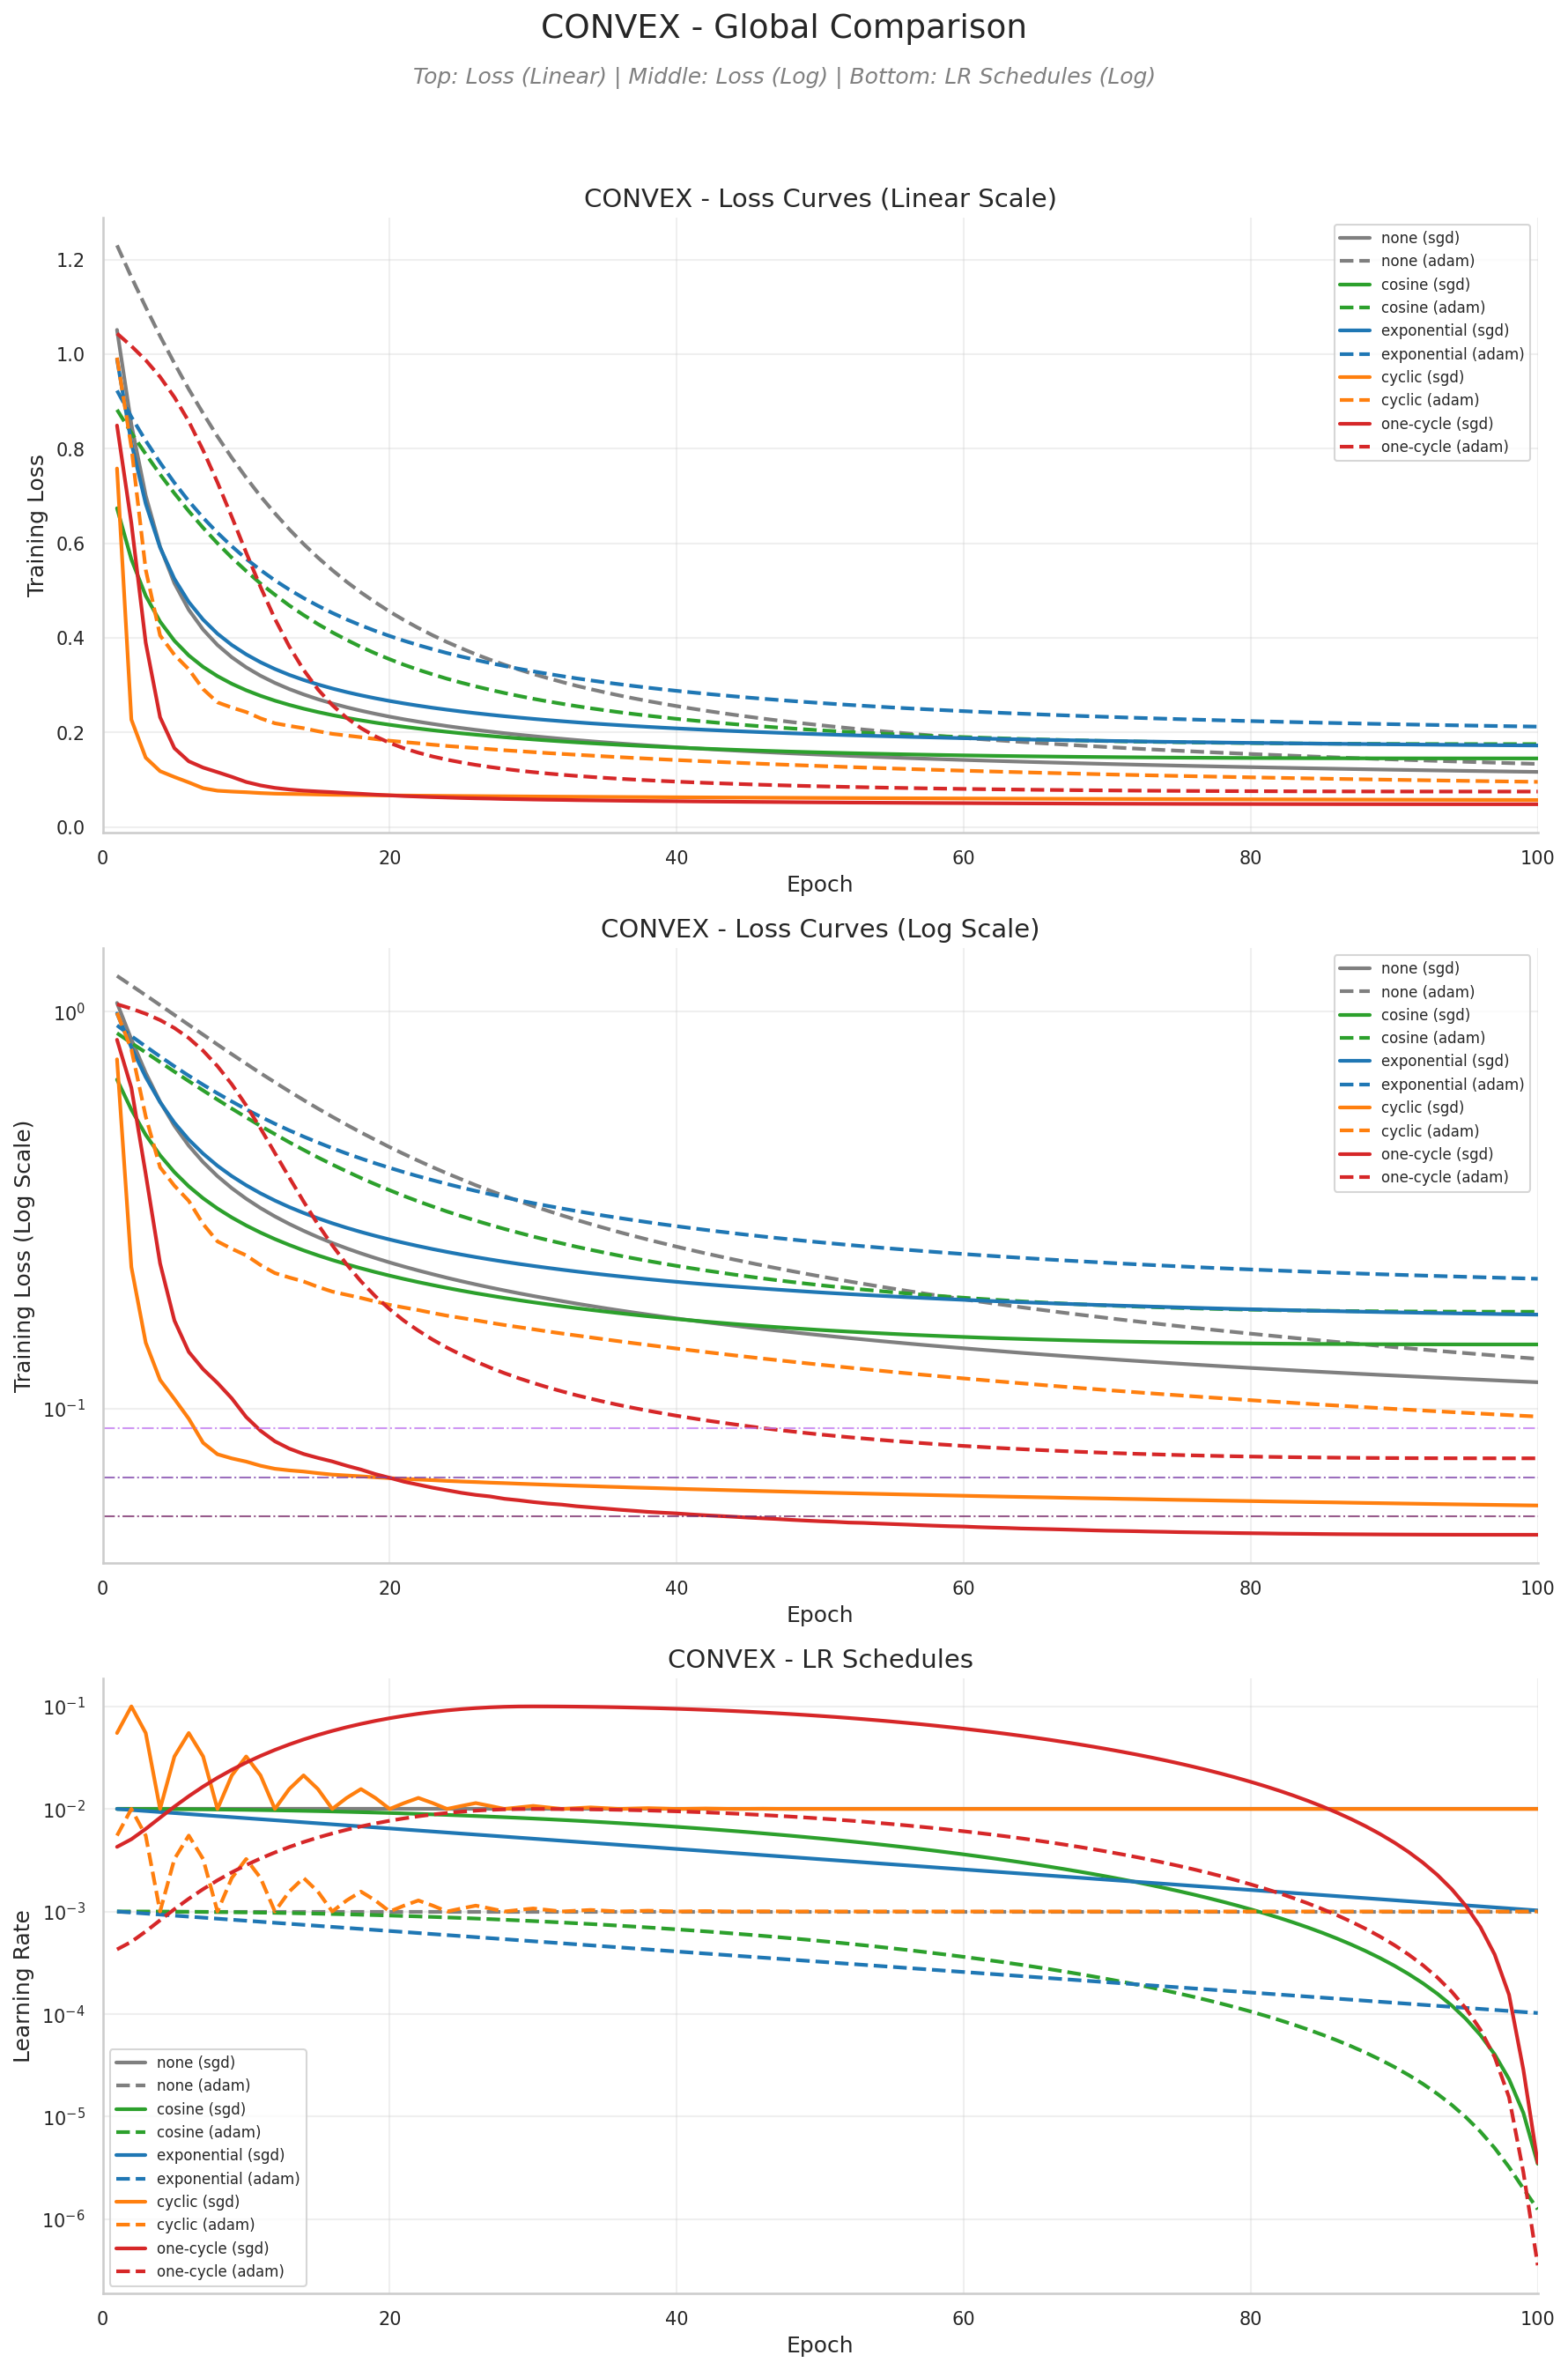

[viz] Saved: ../reports/figures/convex_level2_by_optimizer.png


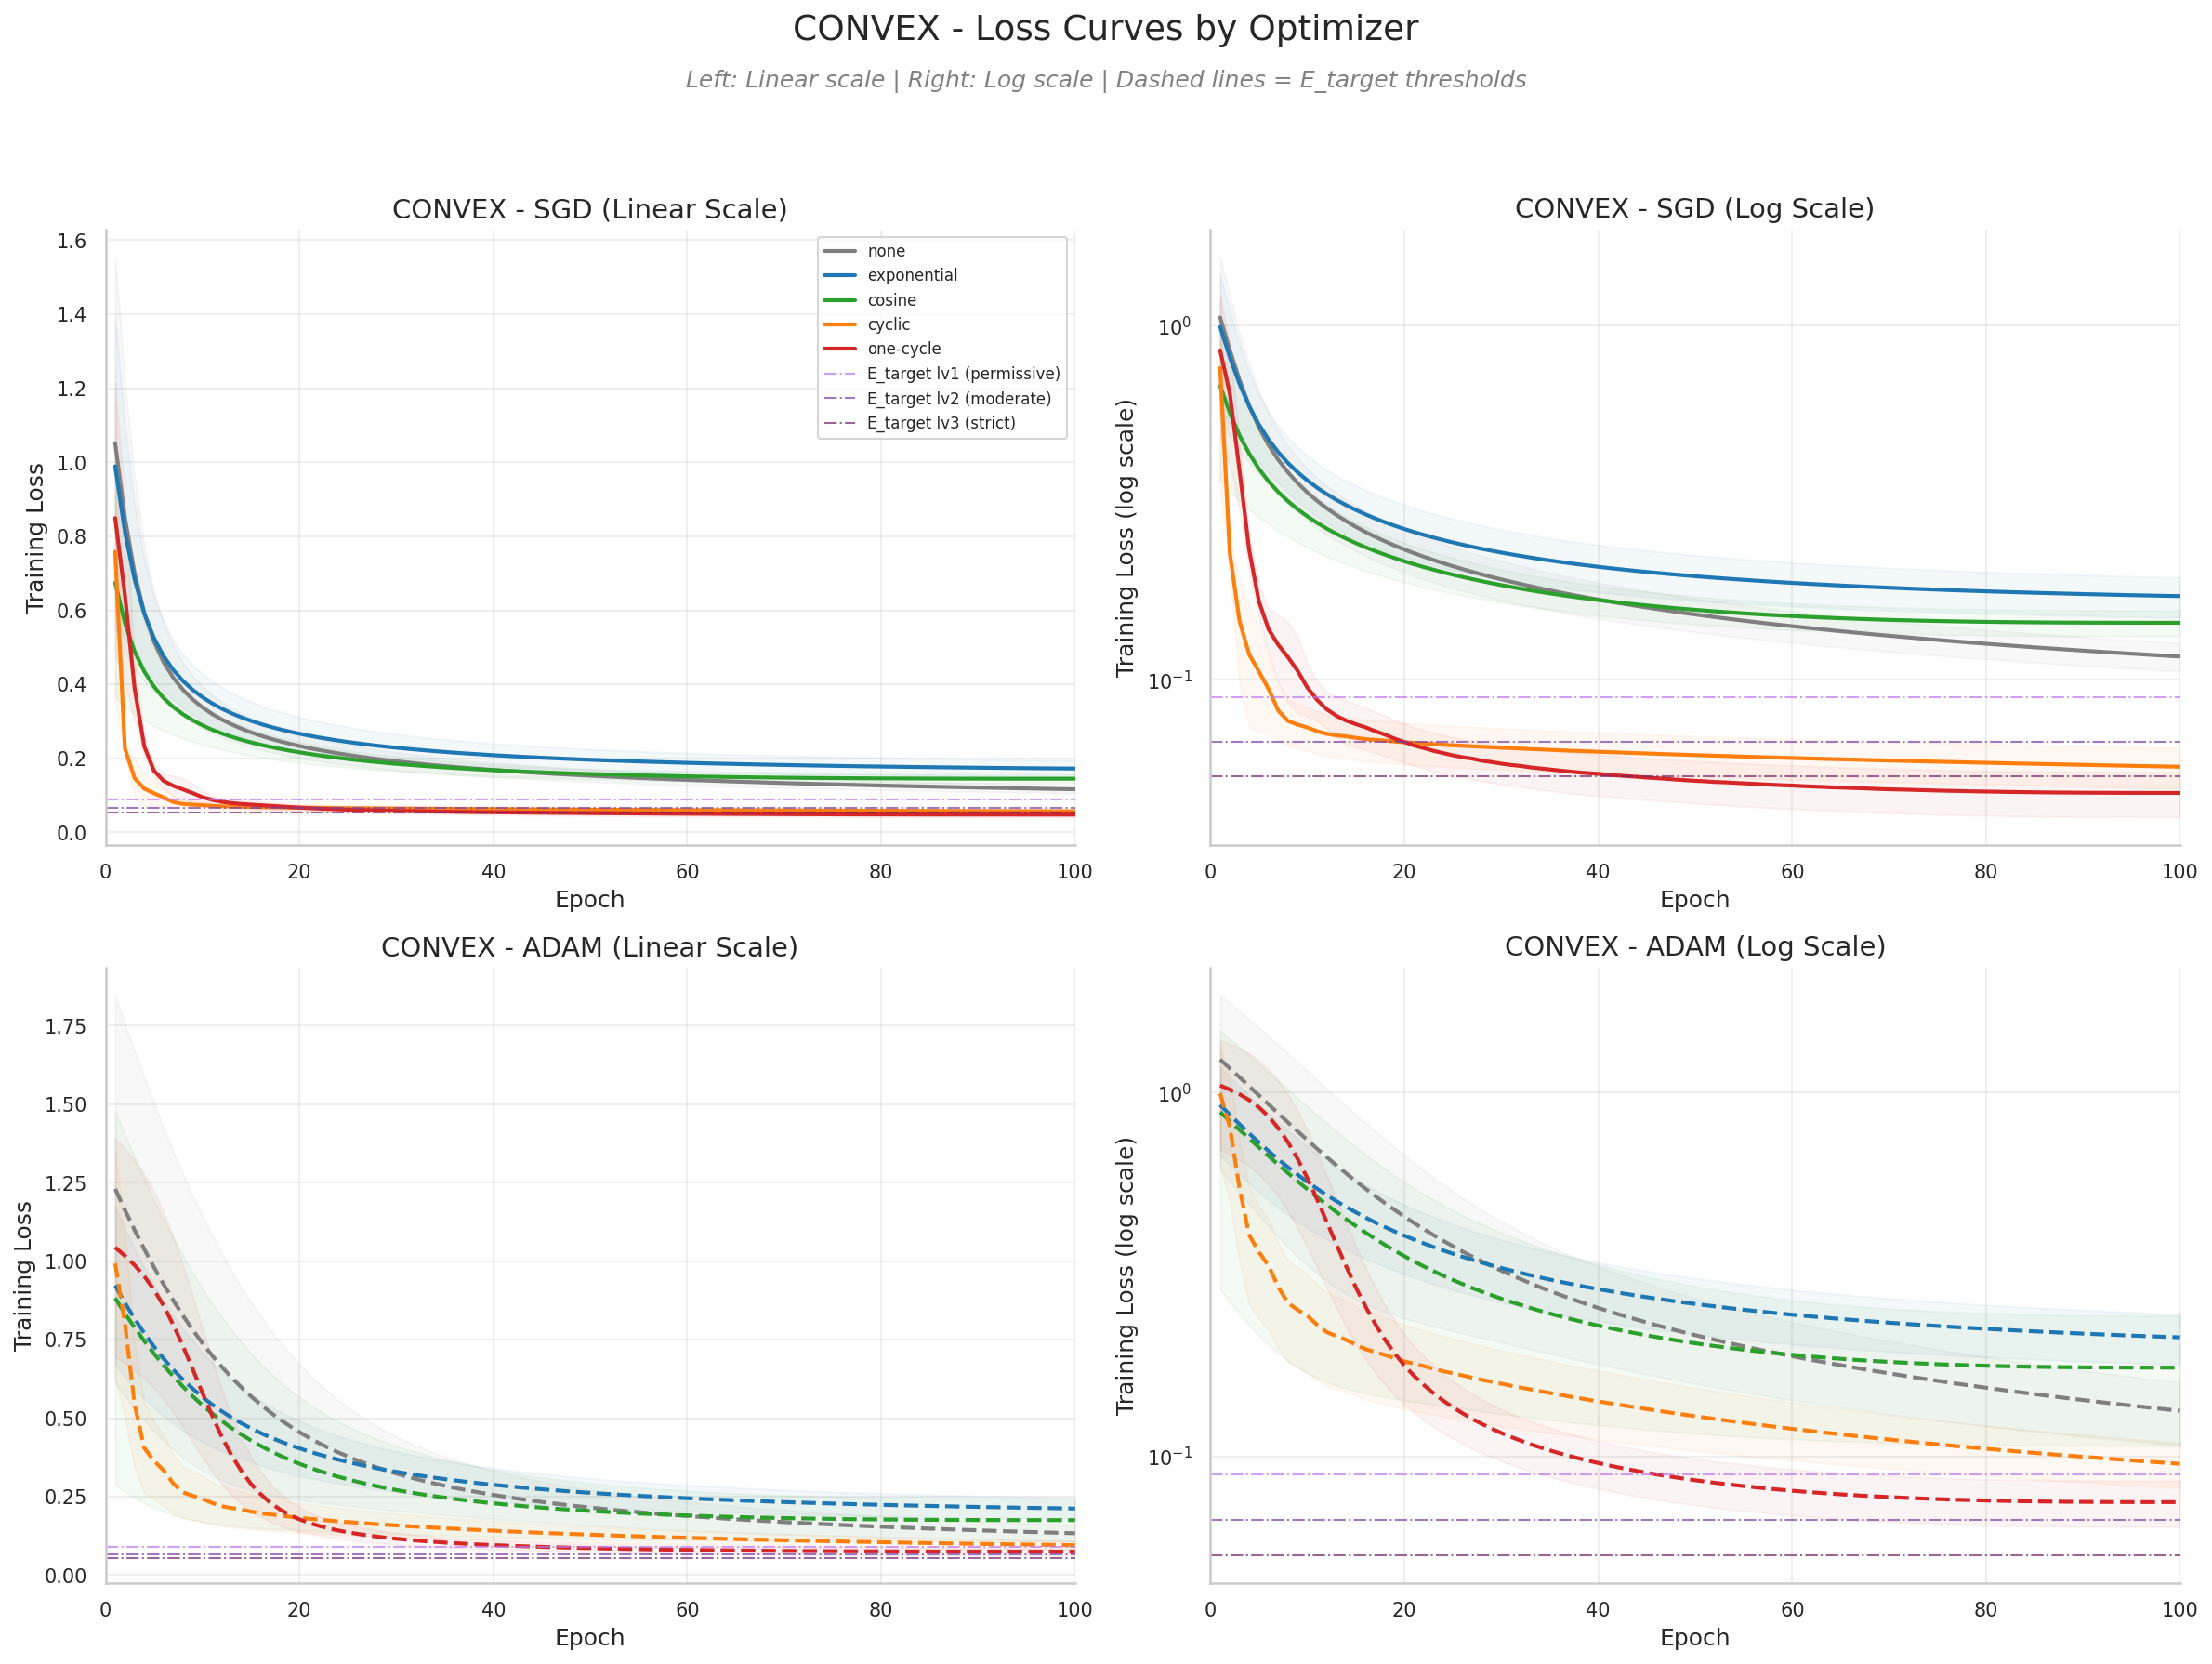

[viz] Saved: ../reports/figures/convex_level3_seed_variance.png


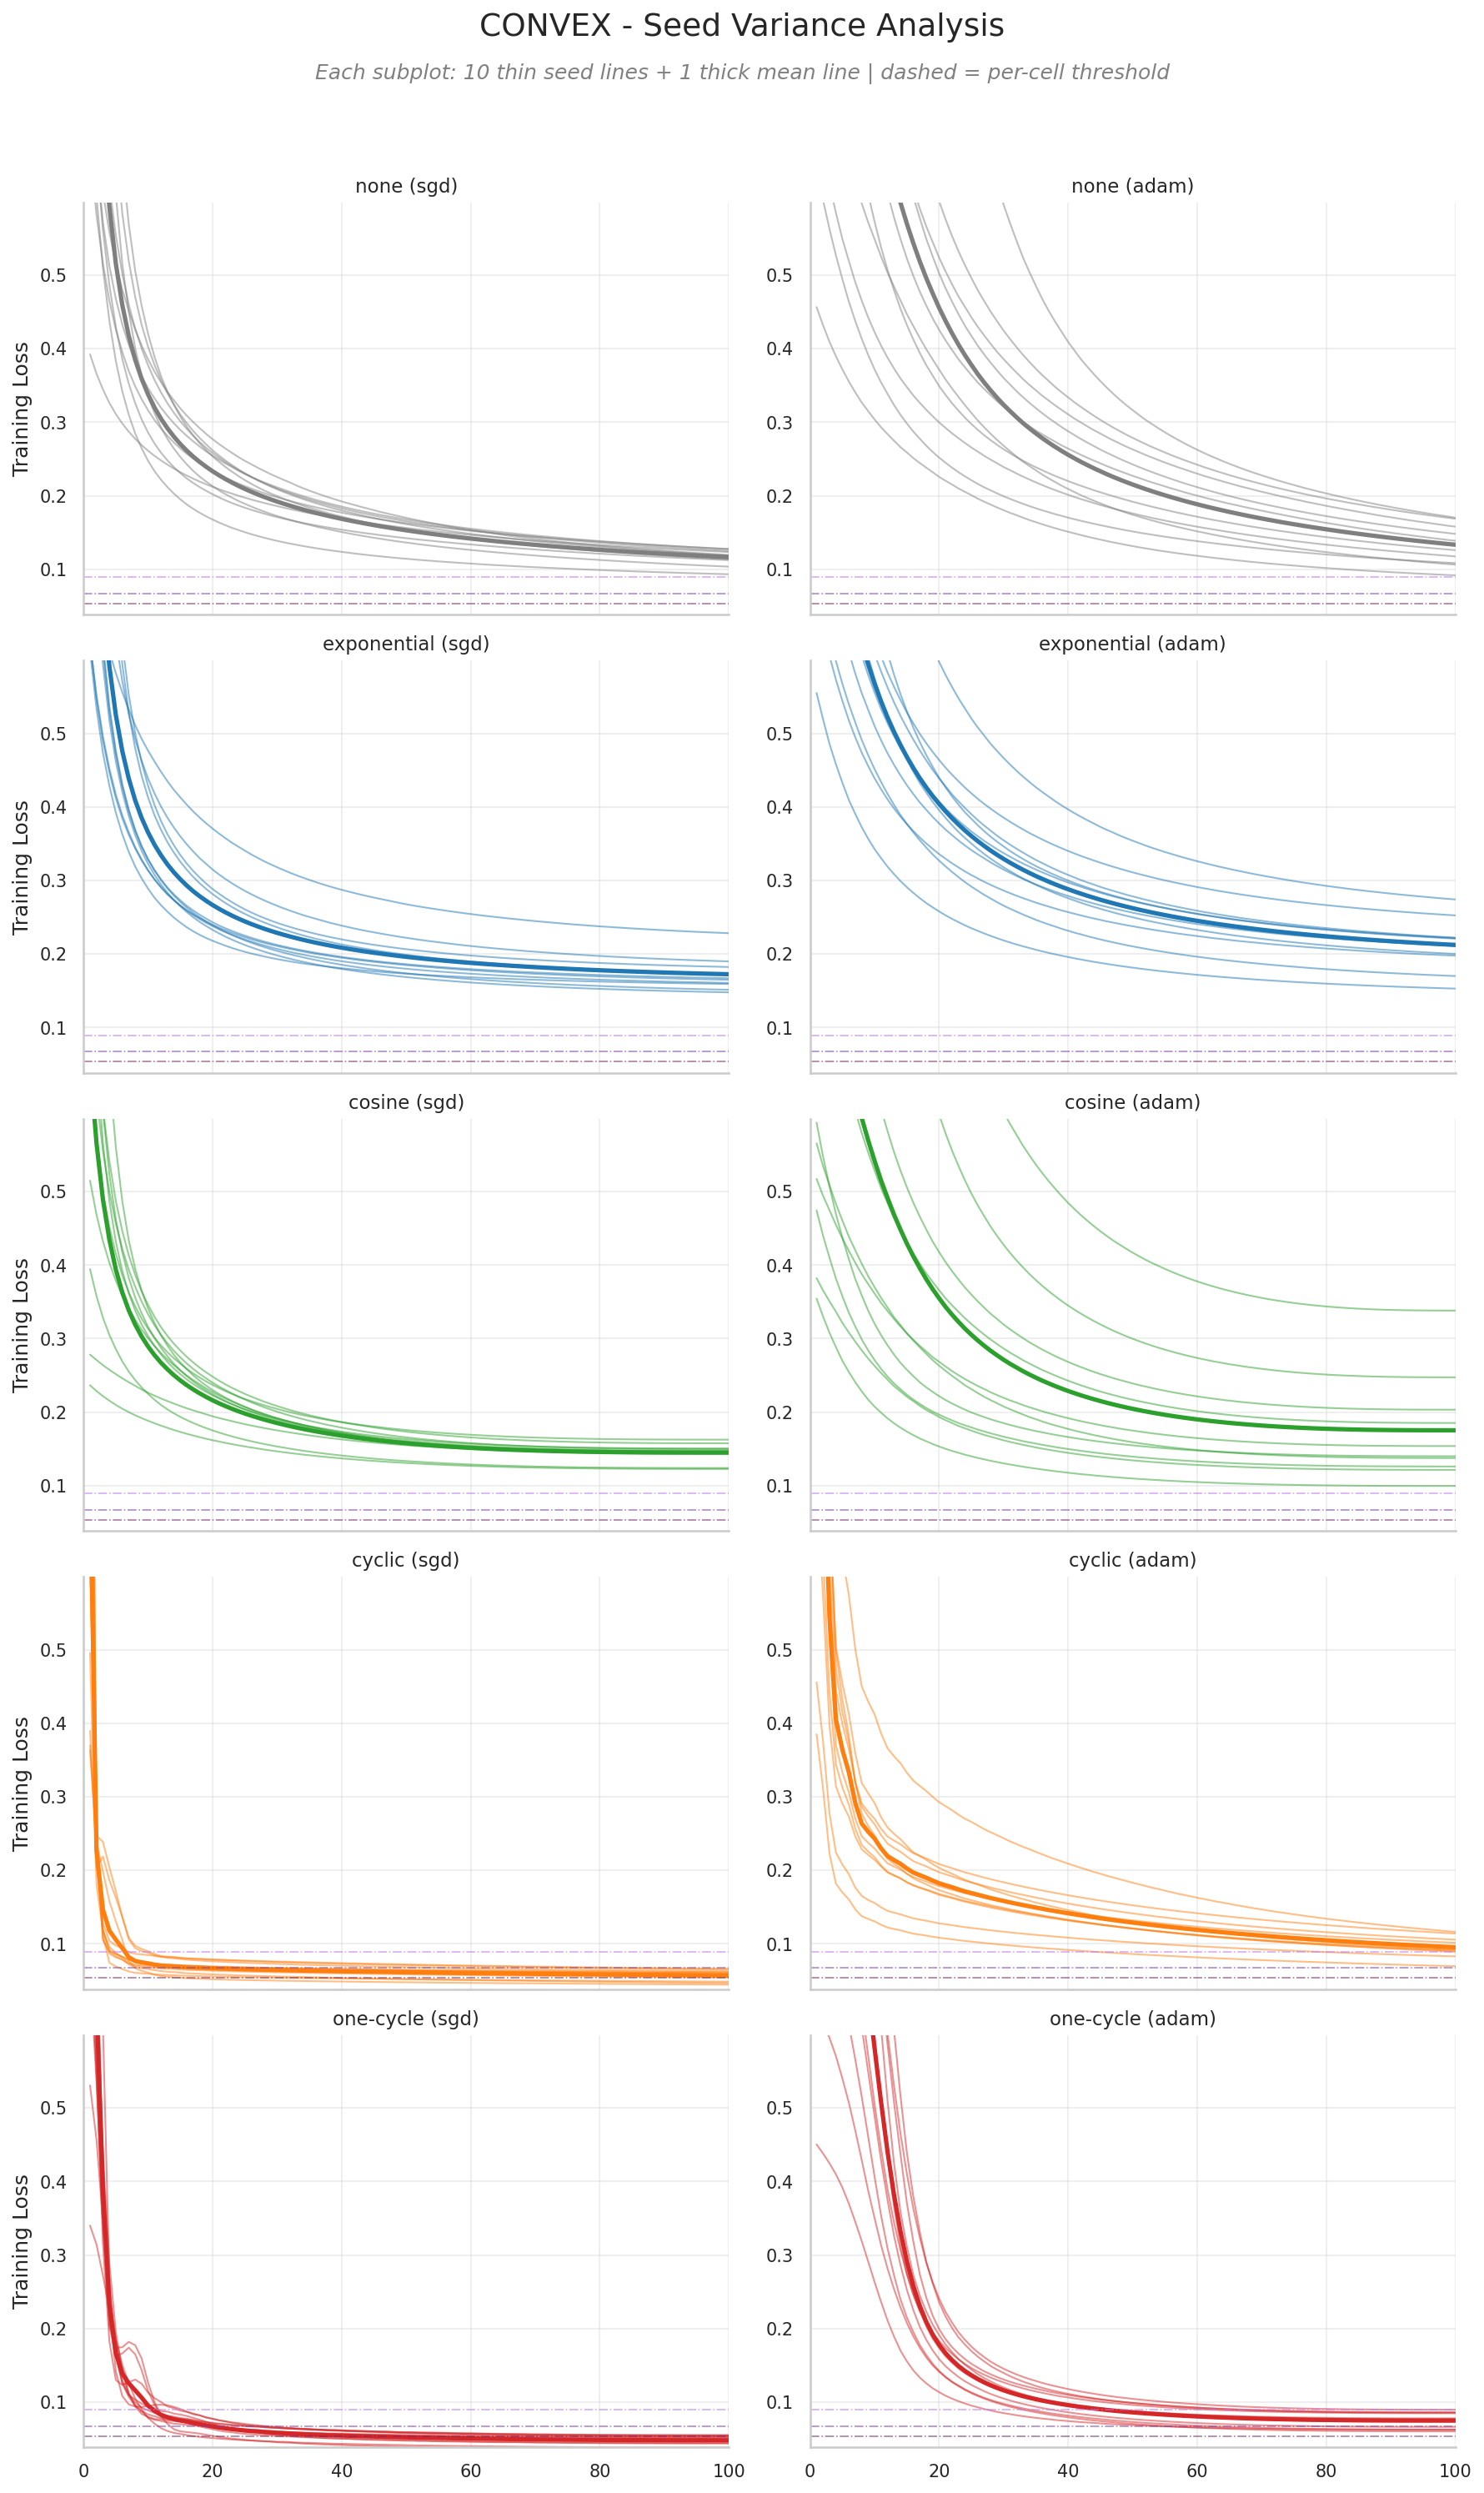

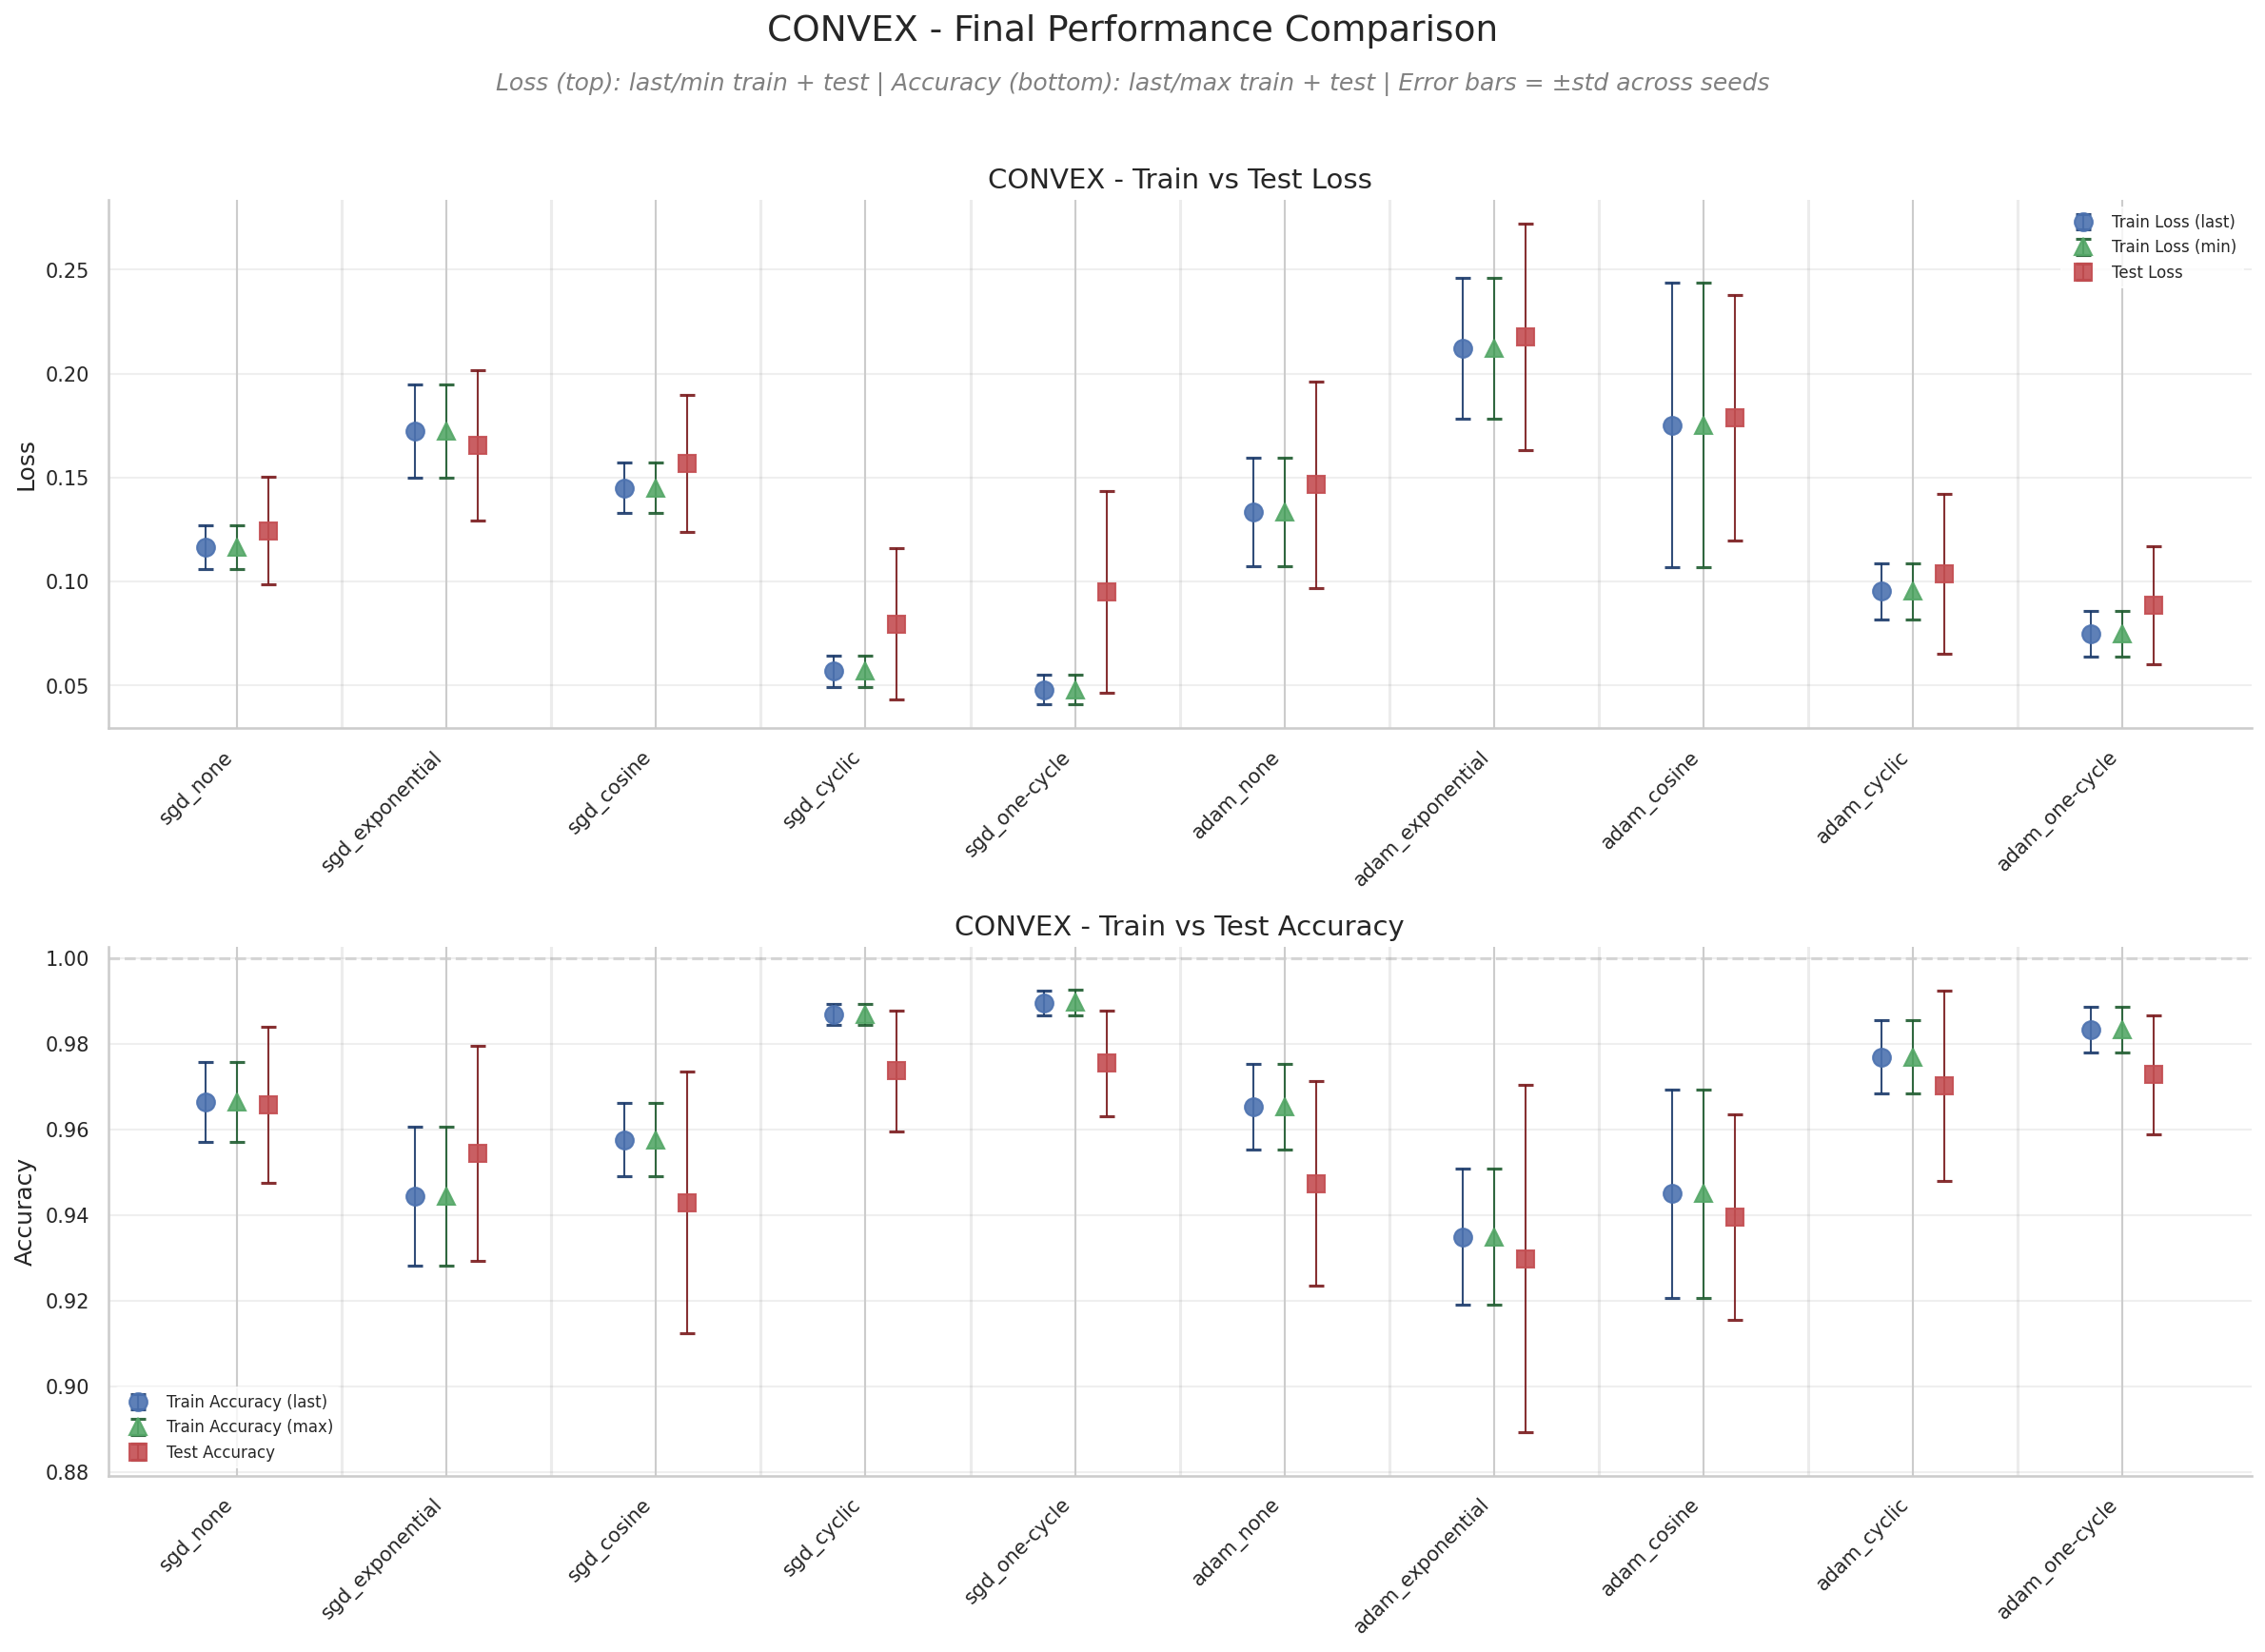

[viz] Saved: ../reports/figures/convex_analytical_a_loss_lr_dual.png


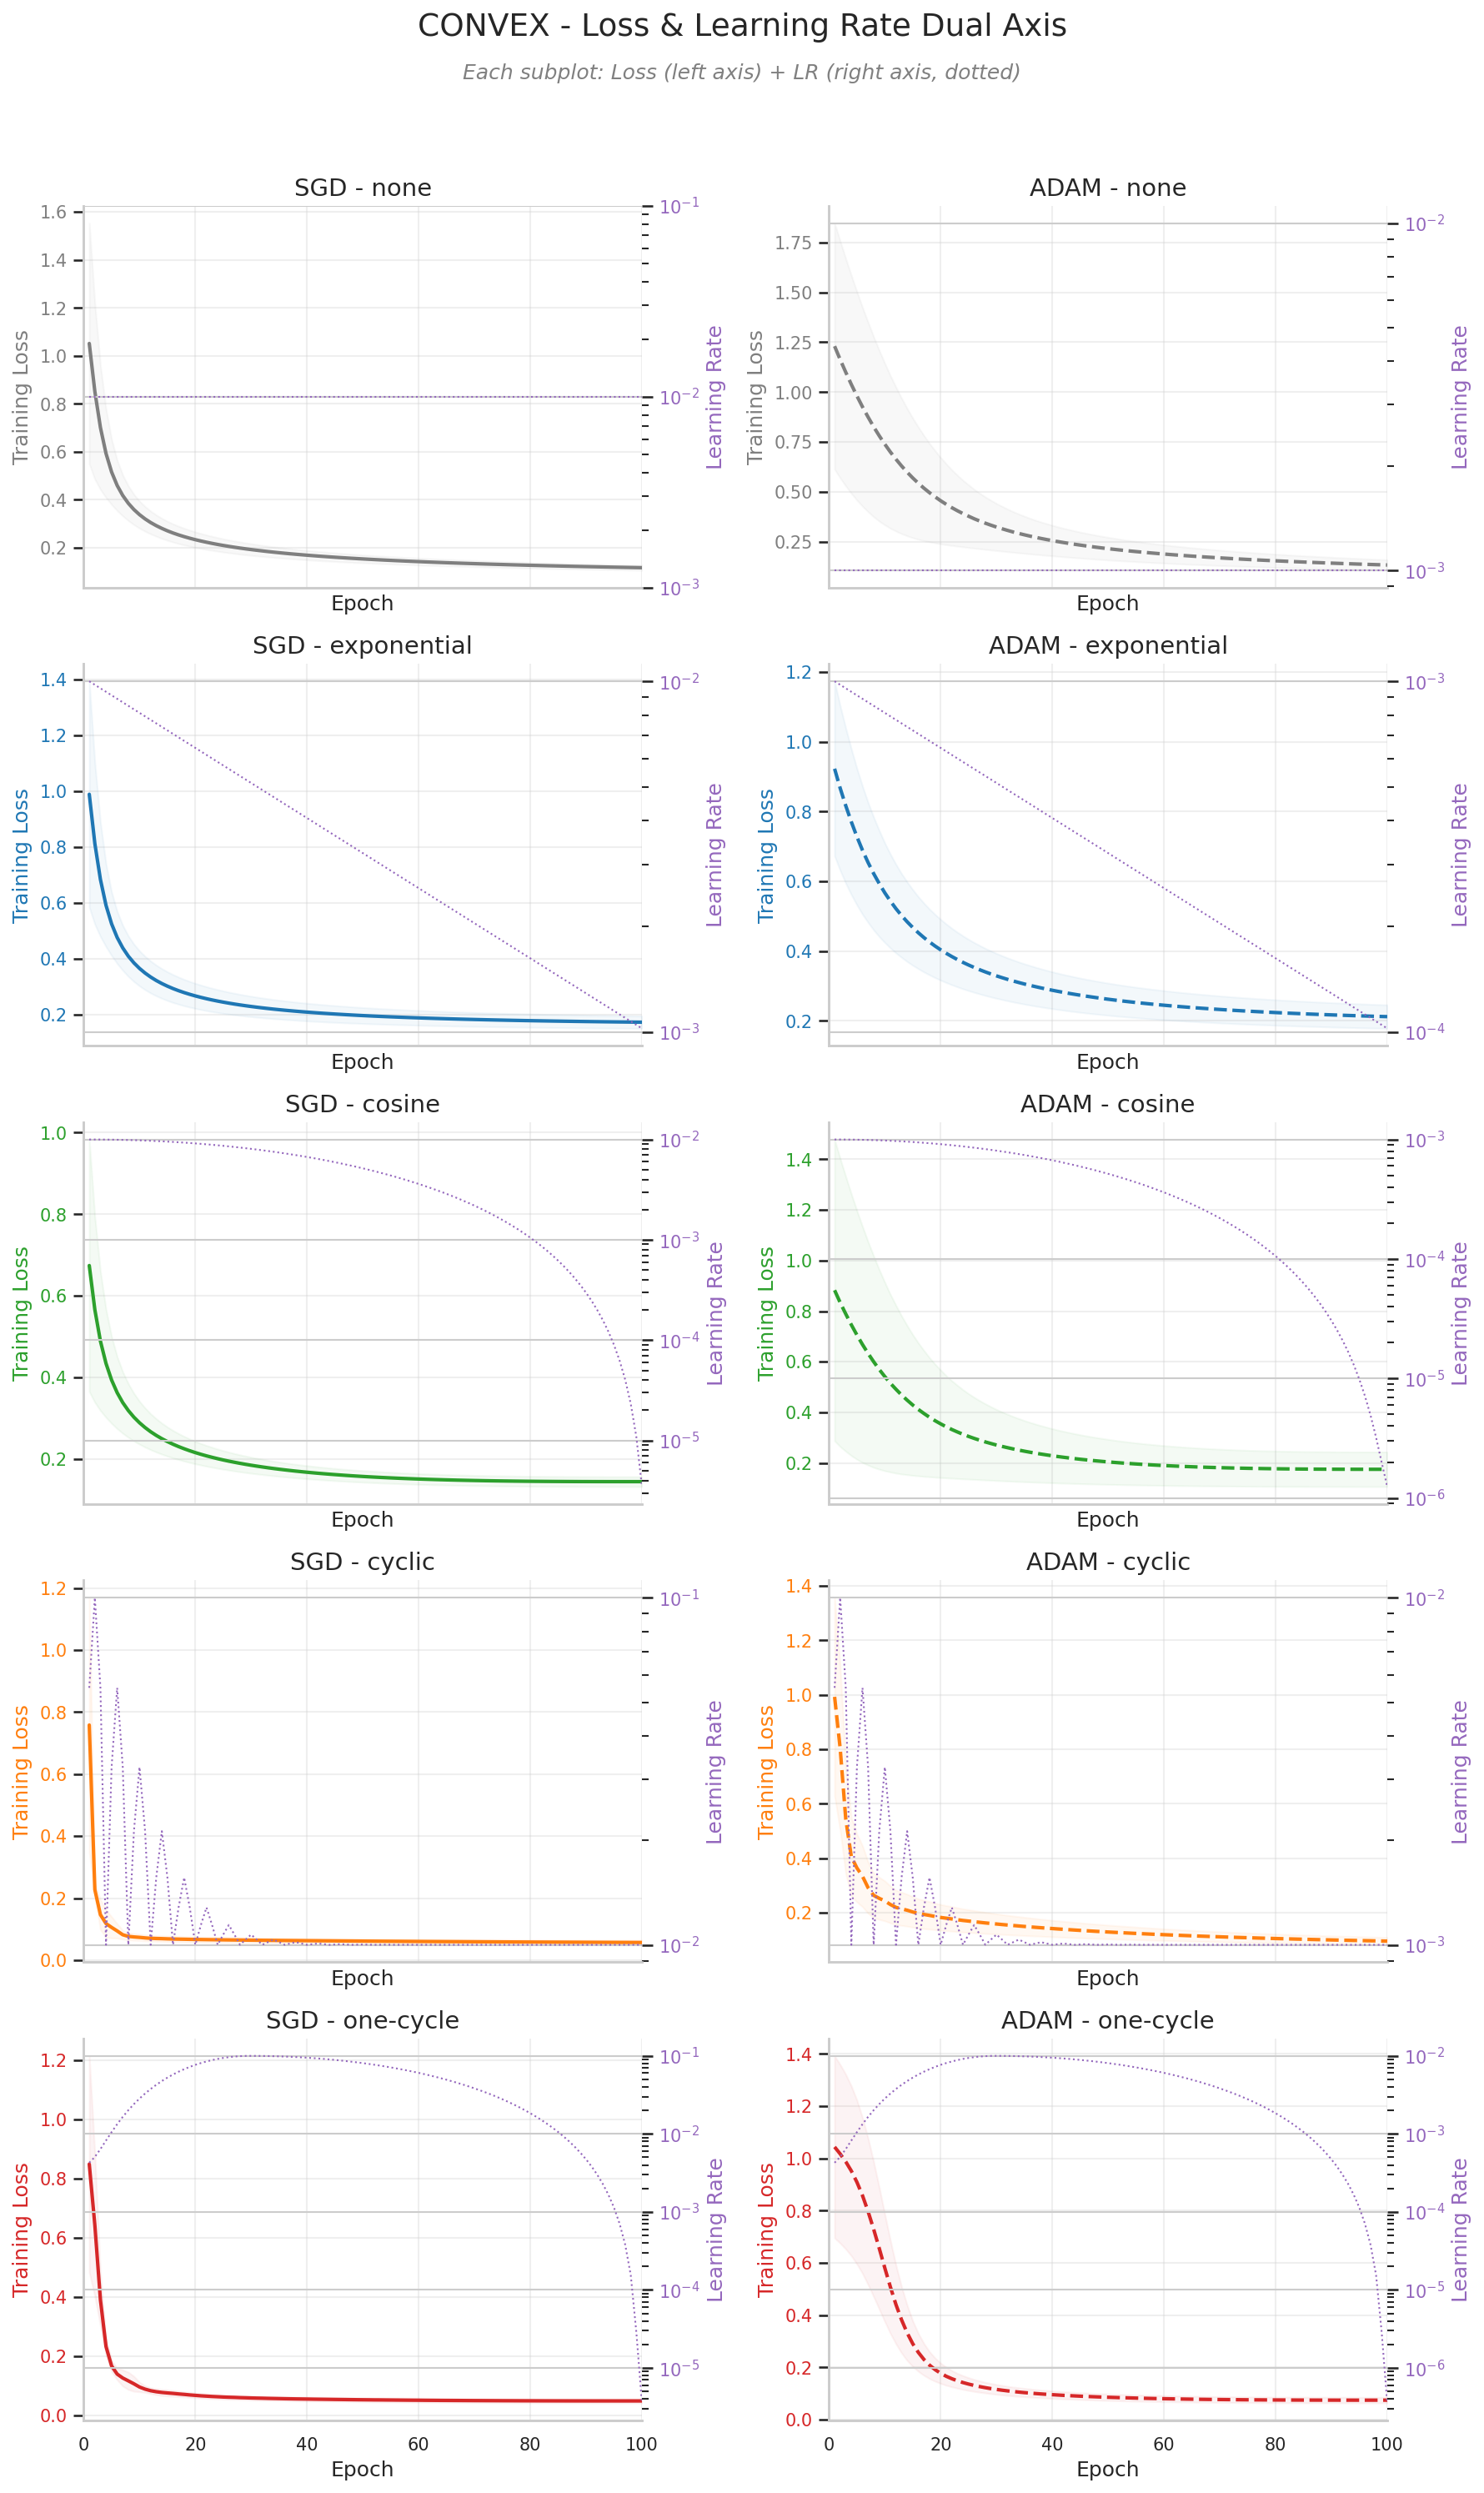

[viz] All plots saved for: convex
[viz] Generating all plots for: non-convex


Saved 5 plot files:
  - ../reports/figures/convex_level1_global_comparison.png
  - ../reports/figures/convex_level2_by_optimizer.png
  - ../reports/figures/convex_level3_seed_variance.png
  - ../reports/figures/convex_level4_final_performance.png
  - ../reports/figures/convex_analytical_a_loss_lr_dual.png

Generating plots for: NON-CONVEX
L_star = 0.001733, L0 = 0.610164
E_target levels: {'E_target_lv1': 0.05, 'E_target_lv2': 0.025, 'E_target_lv3': 0.01}


[viz] Saved: ../reports/figures/non-convex_level1_global_comparison.png


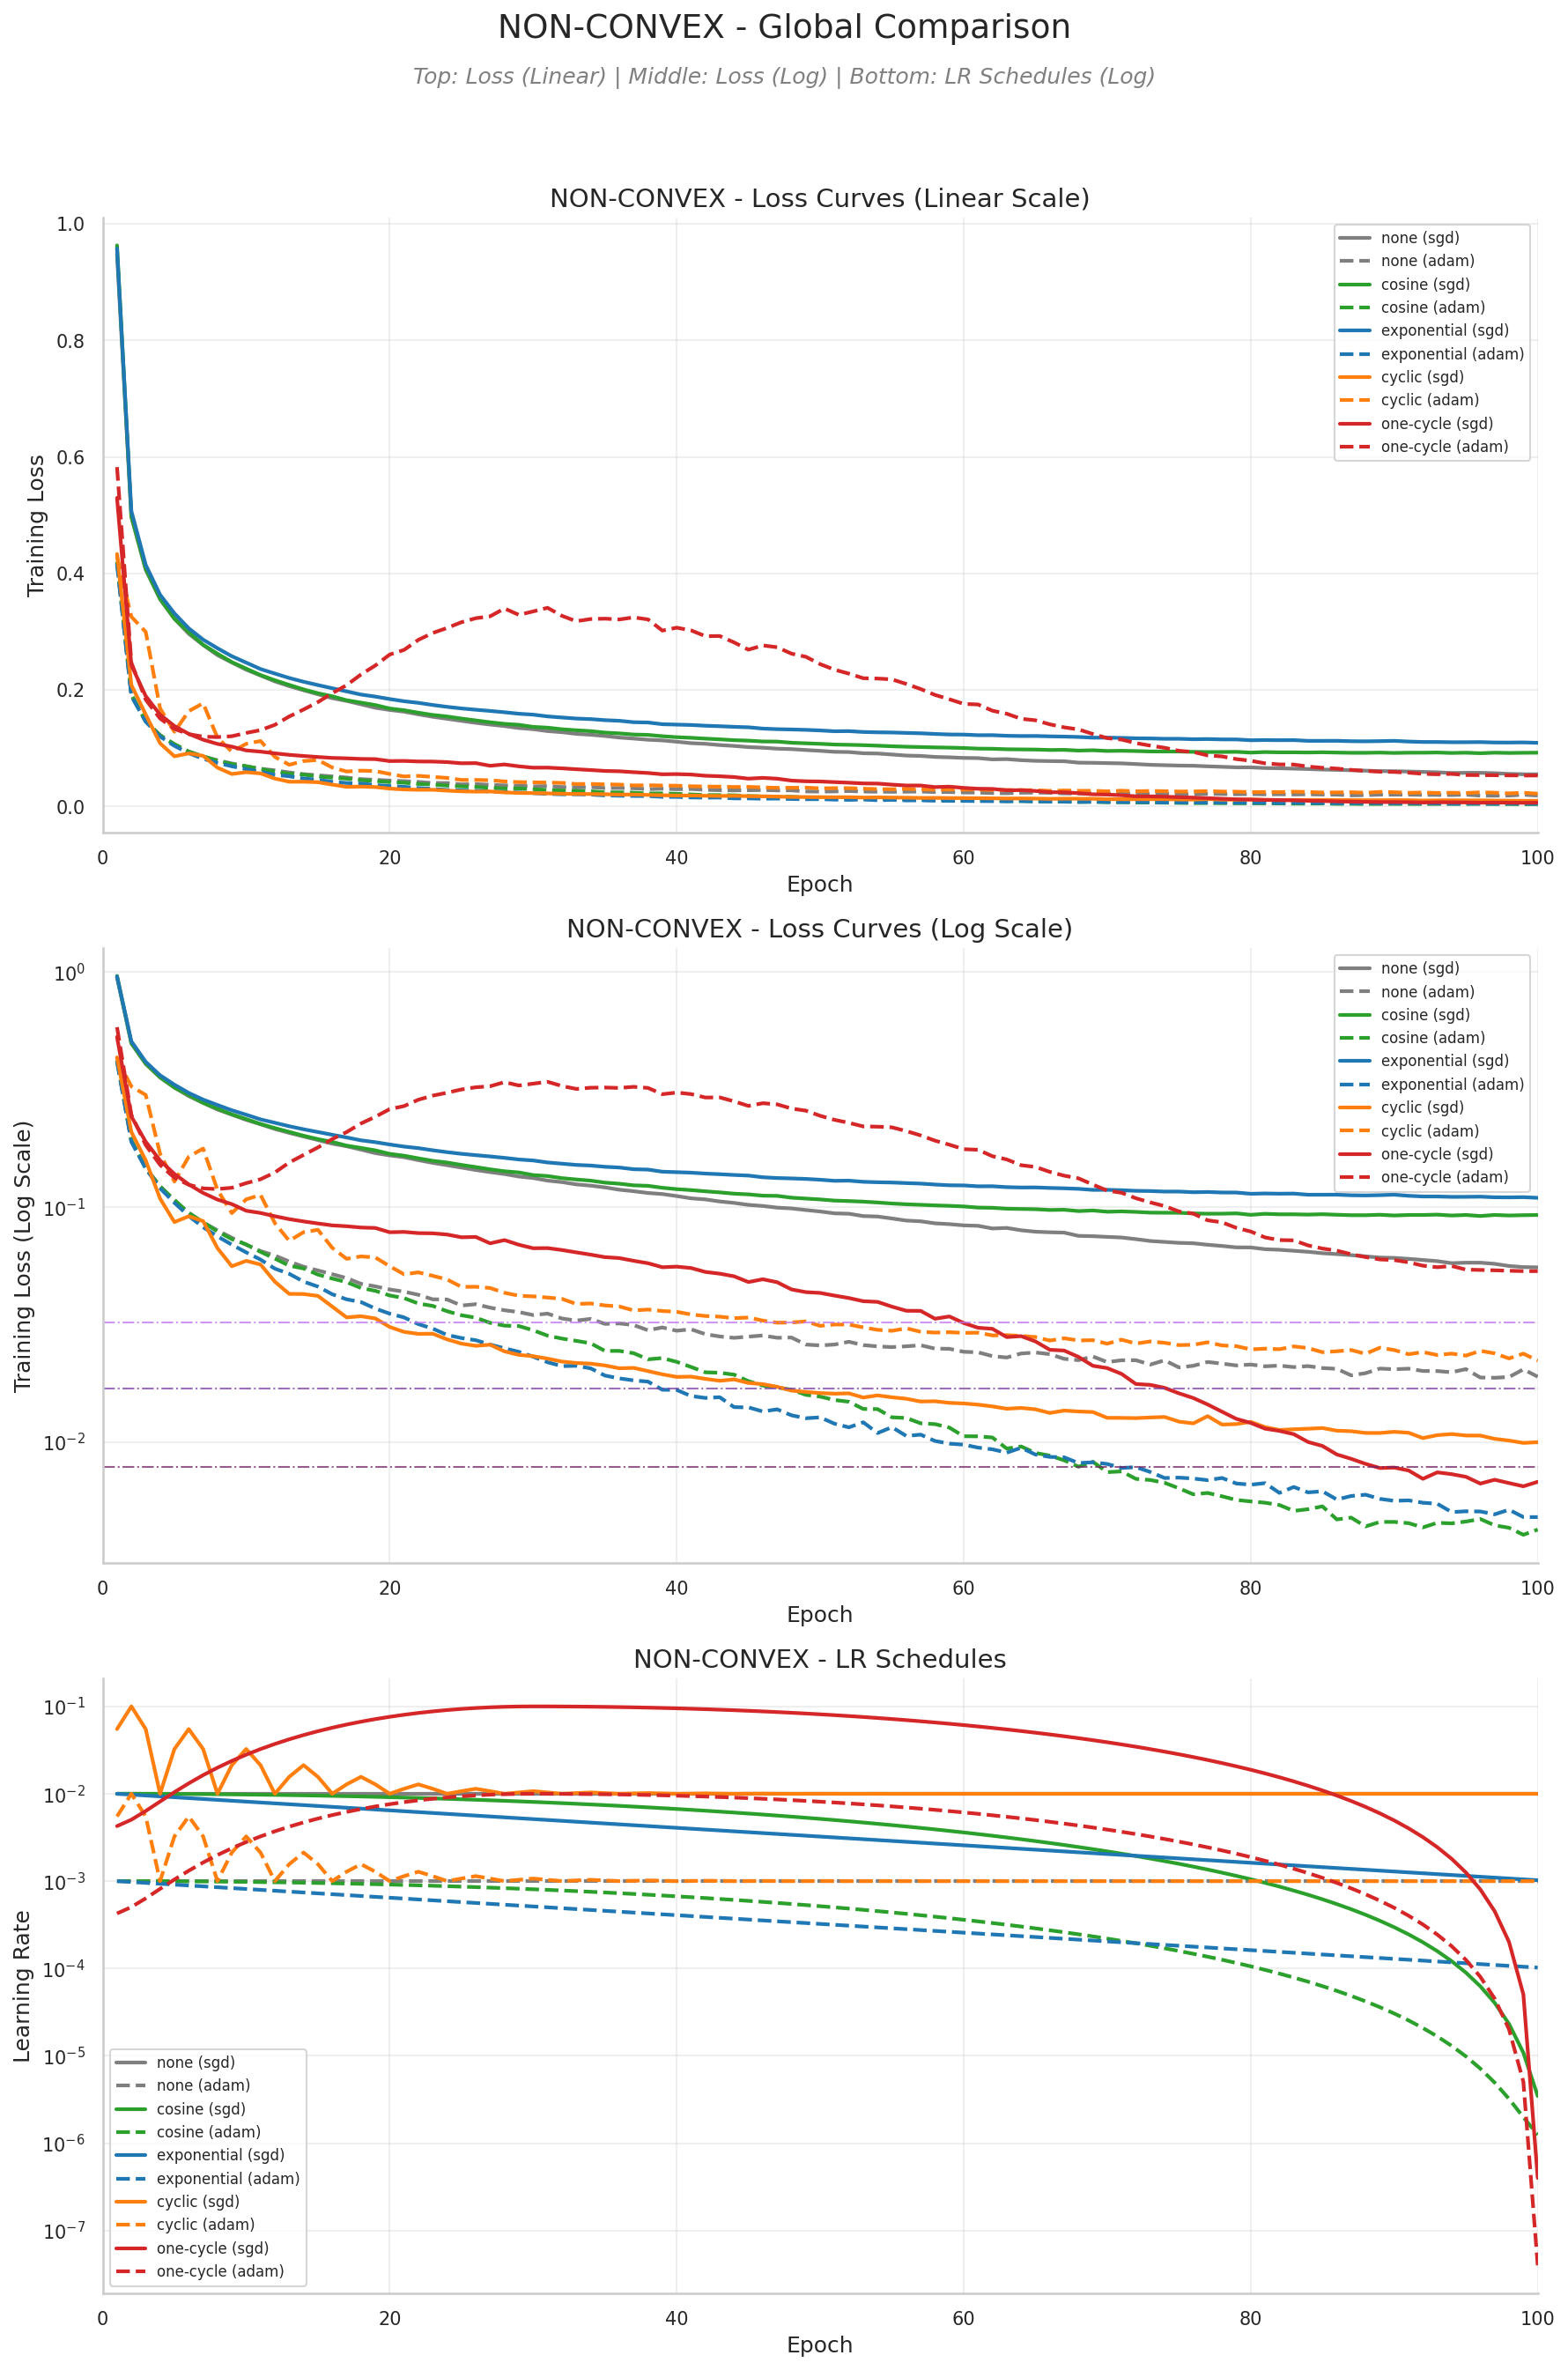

[viz] Saved: ../reports/figures/non-convex_level2_by_optimizer.png


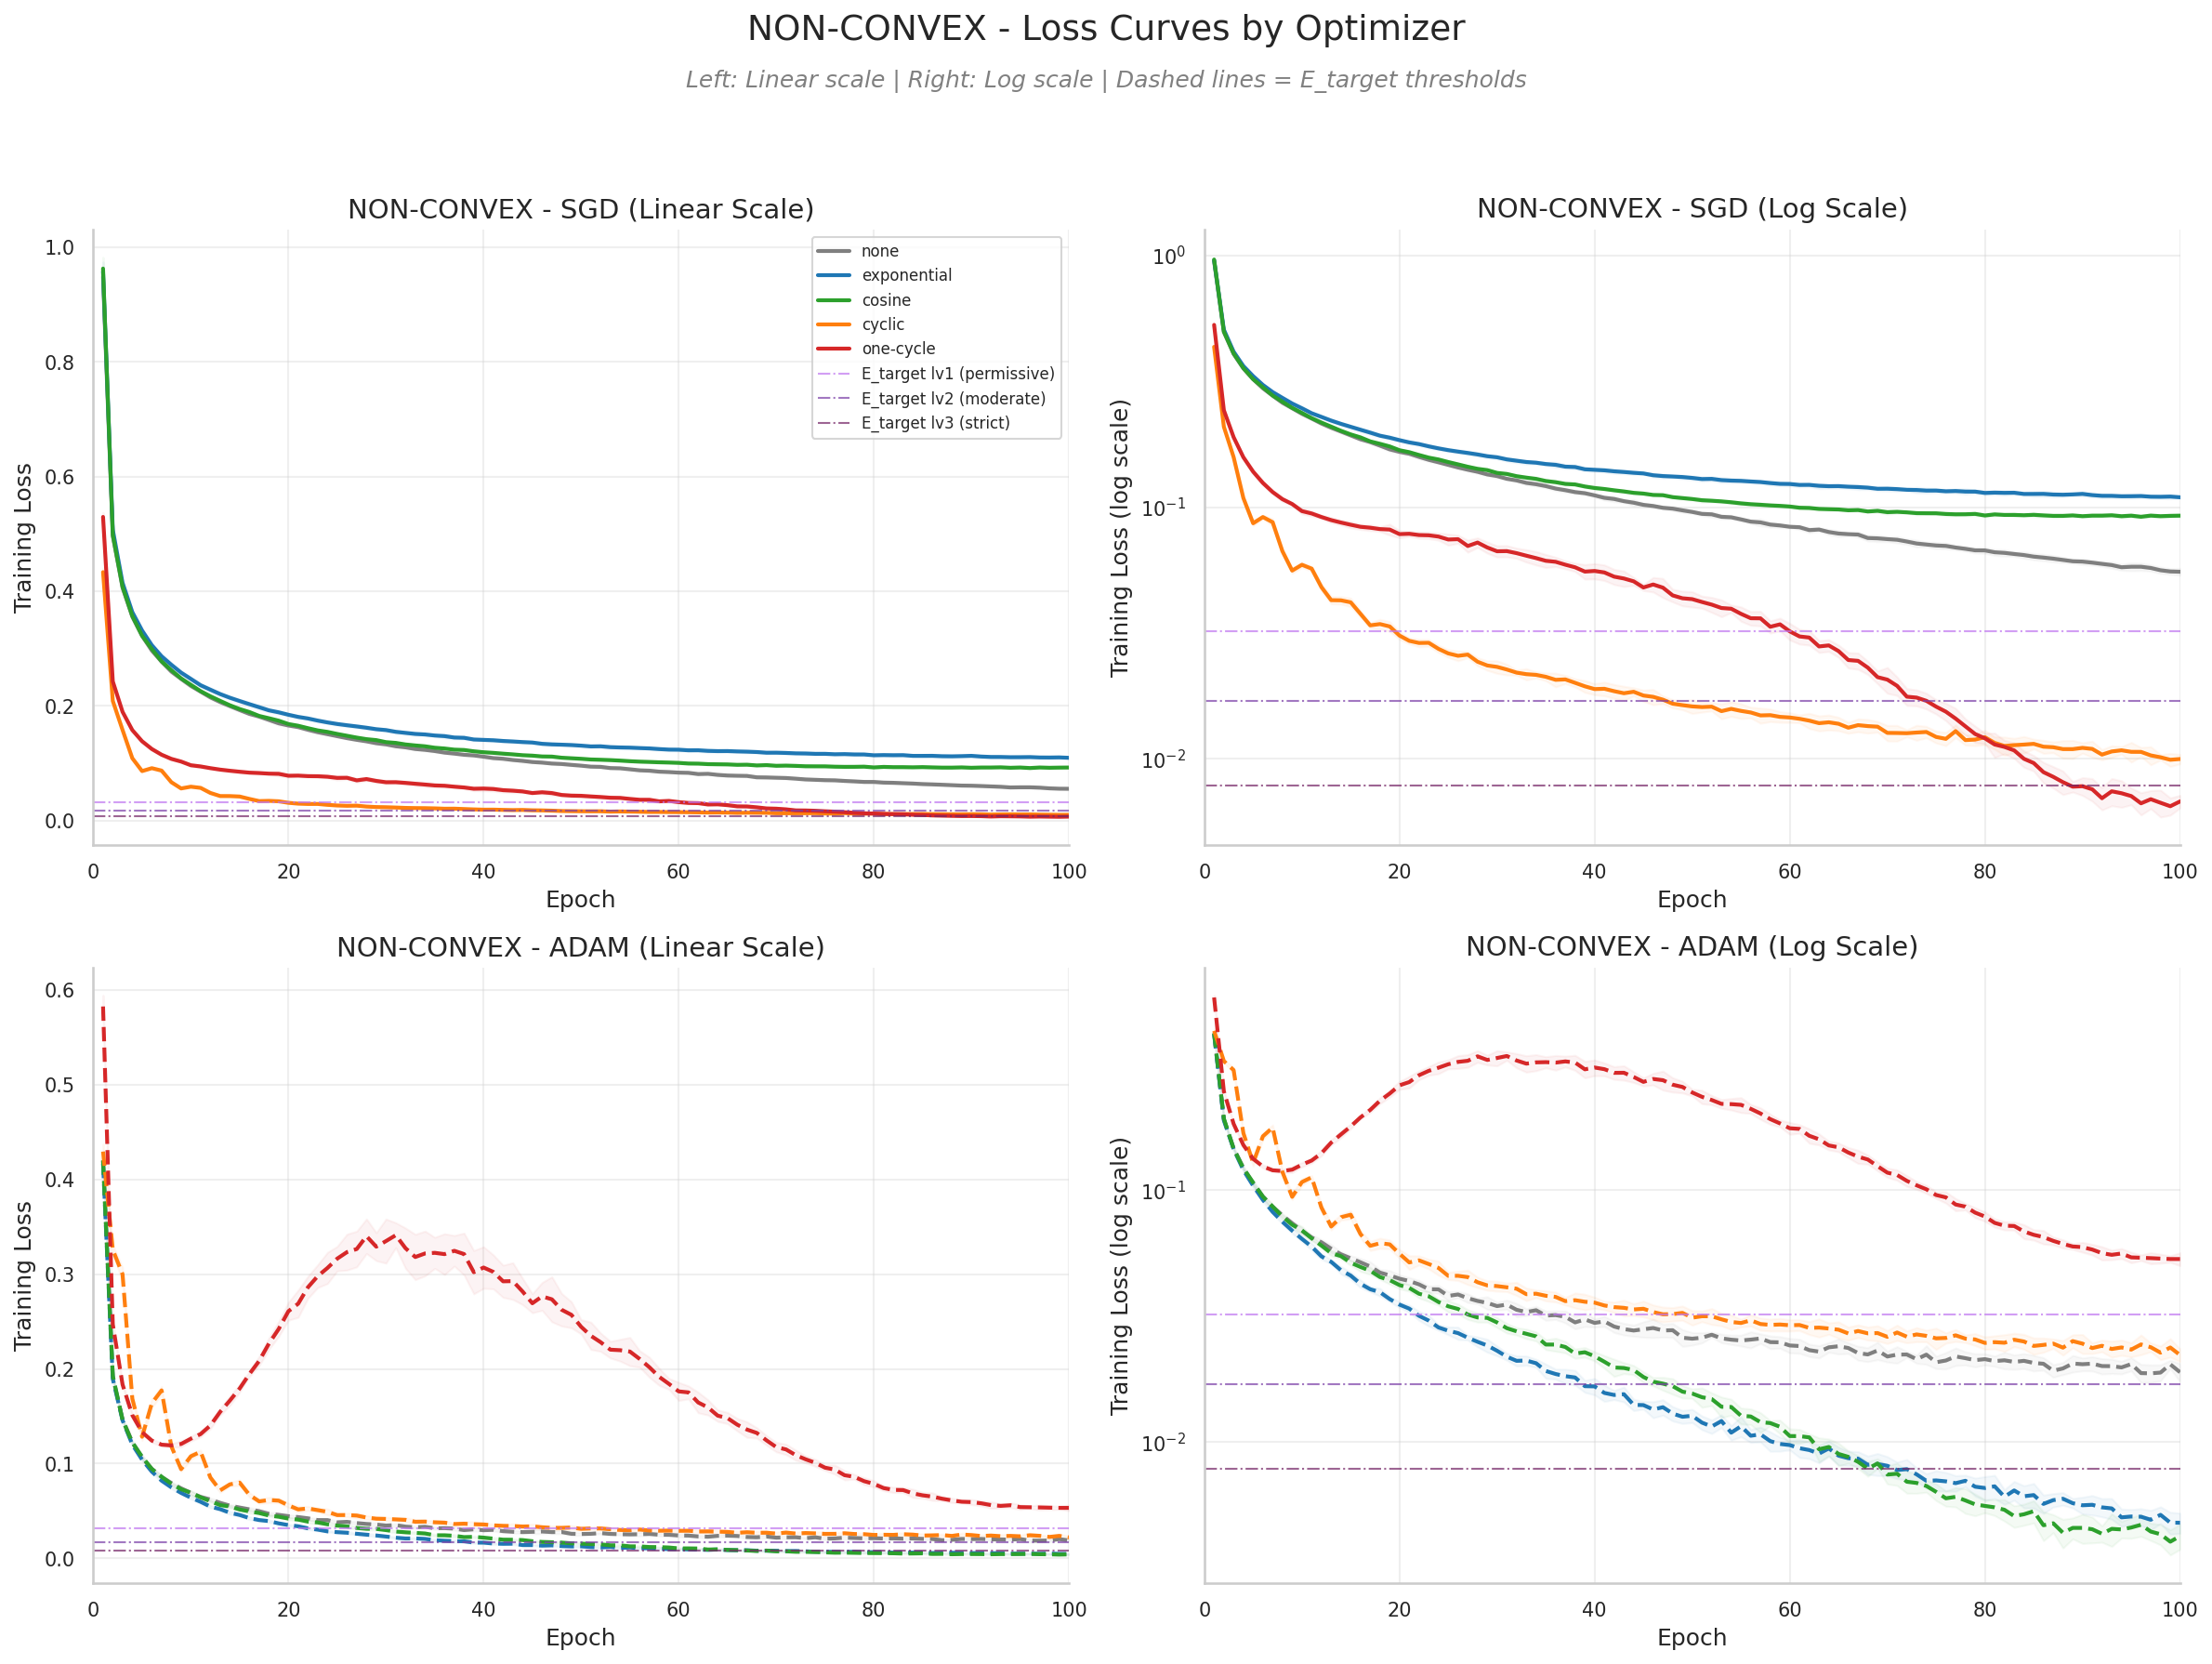

[viz] Saved: ../reports/figures/non-convex_level3_seed_variance.png


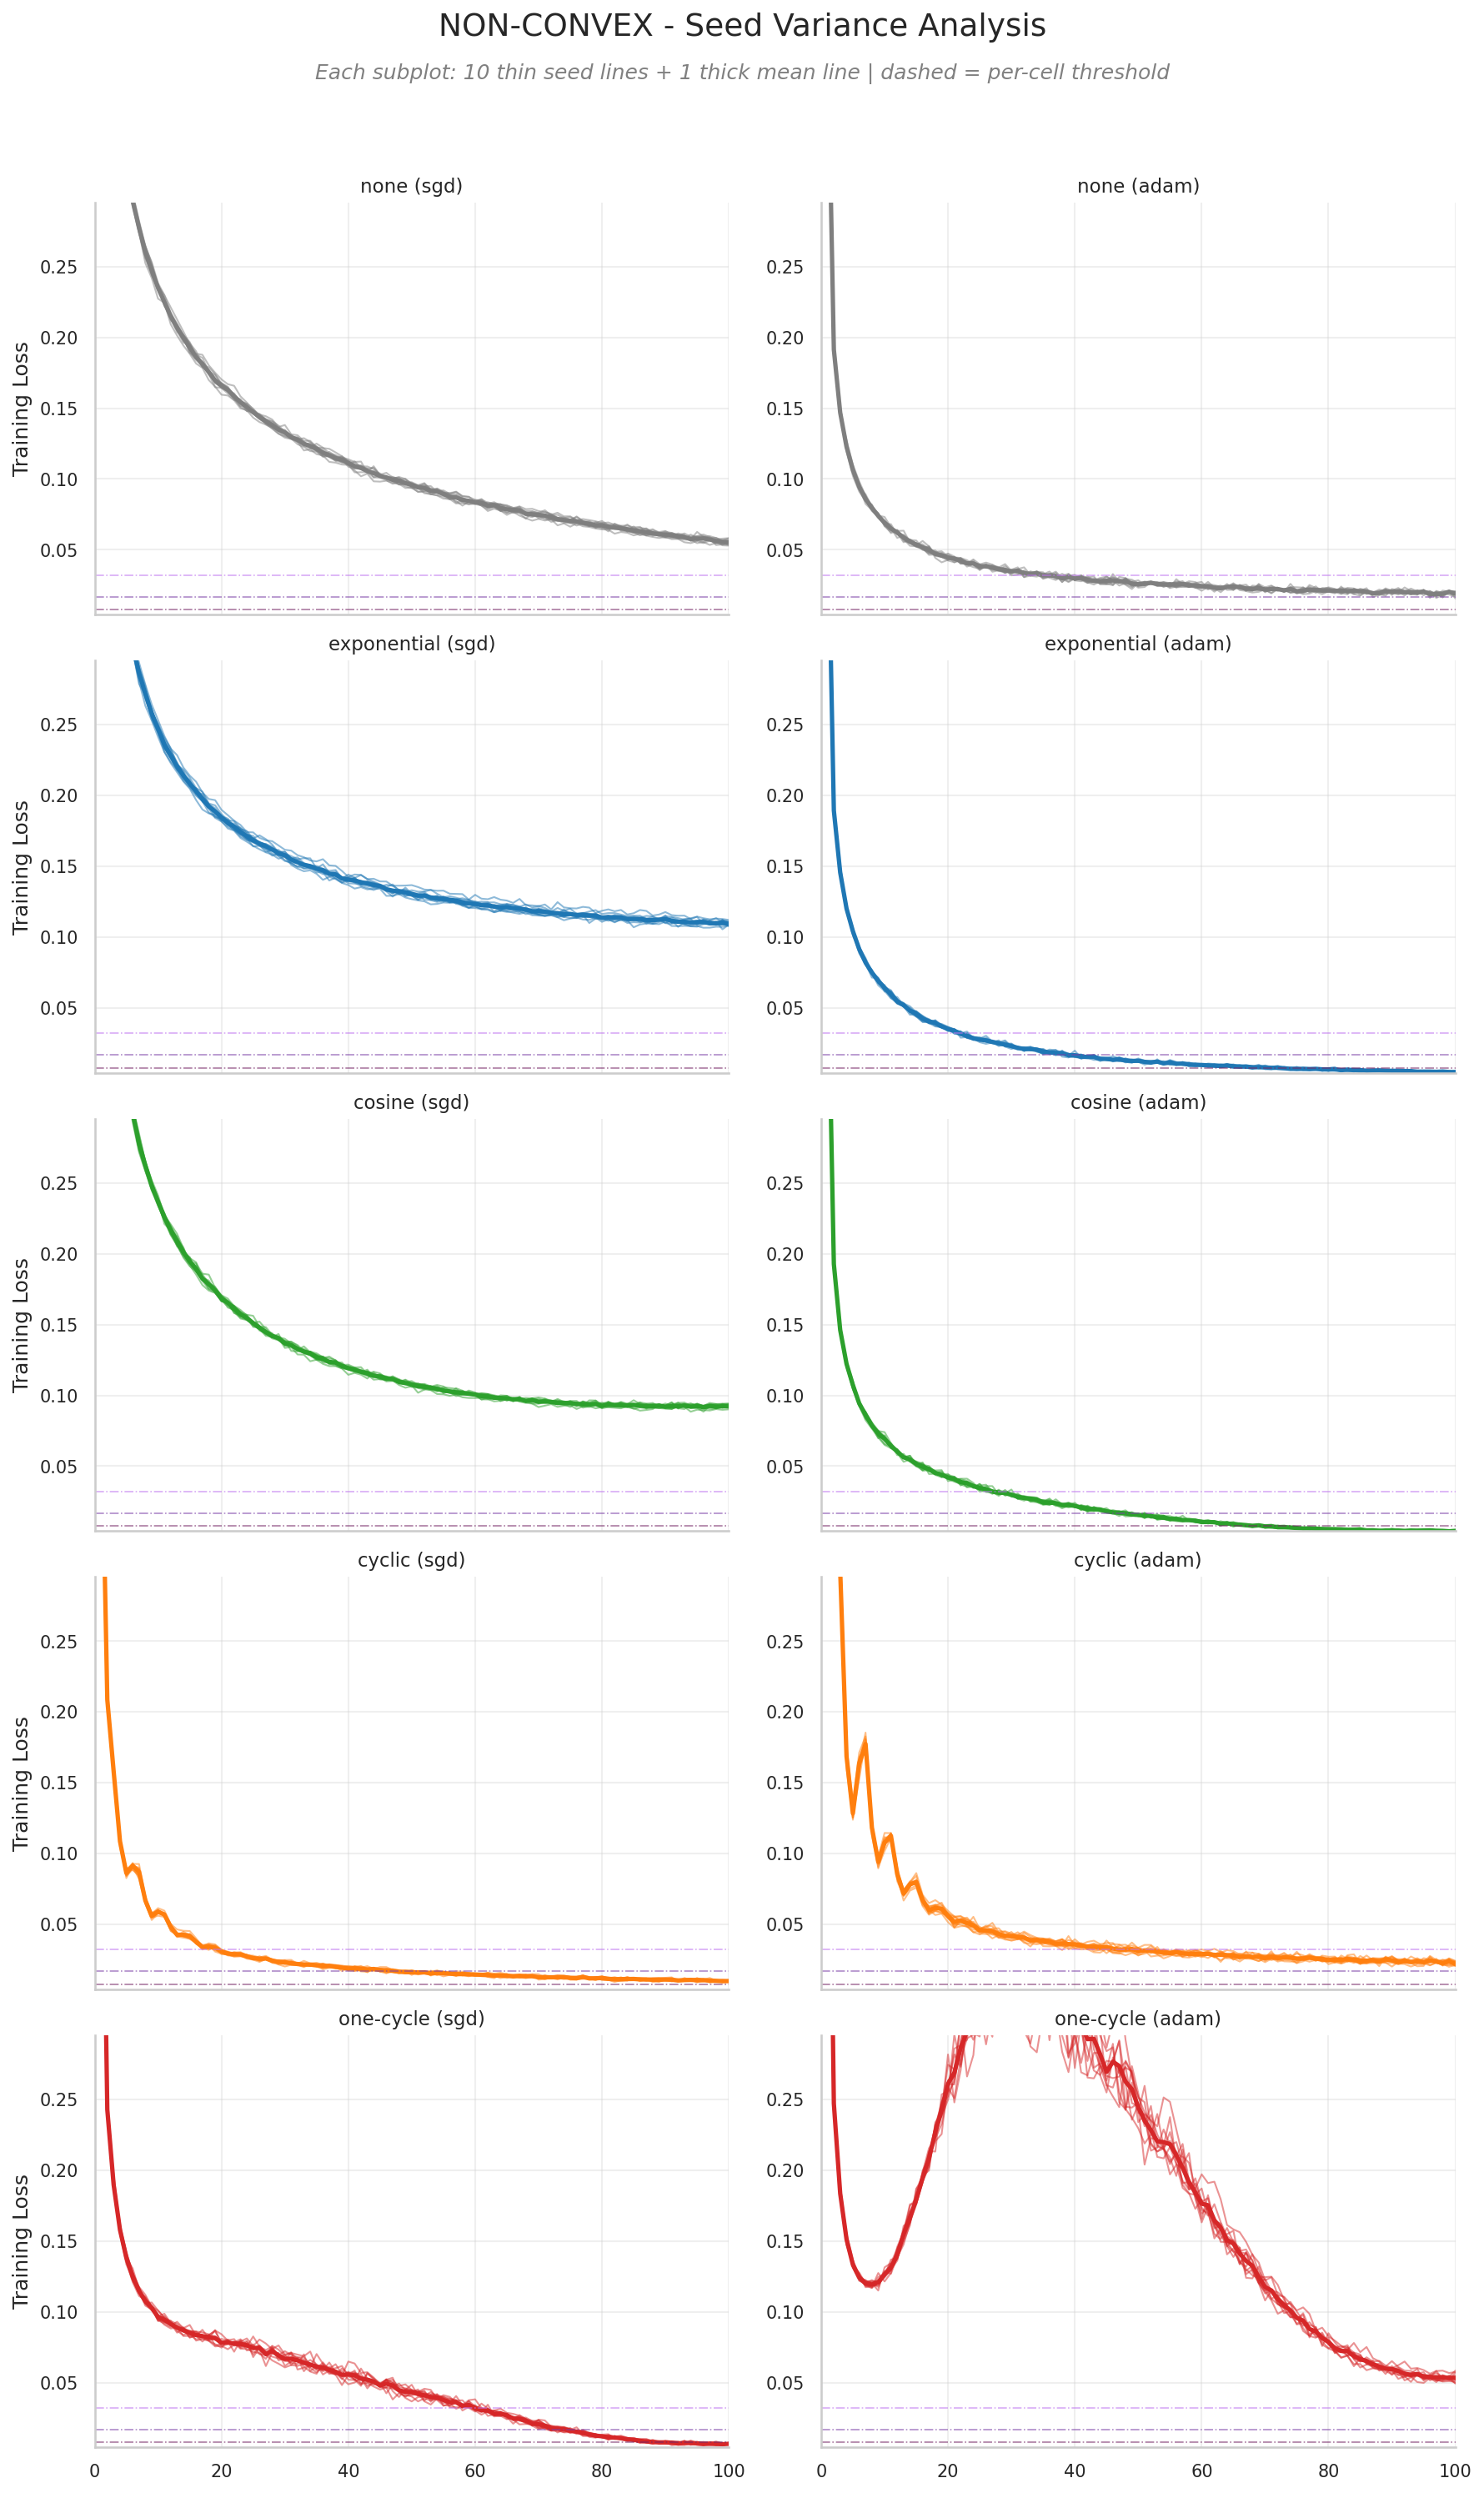

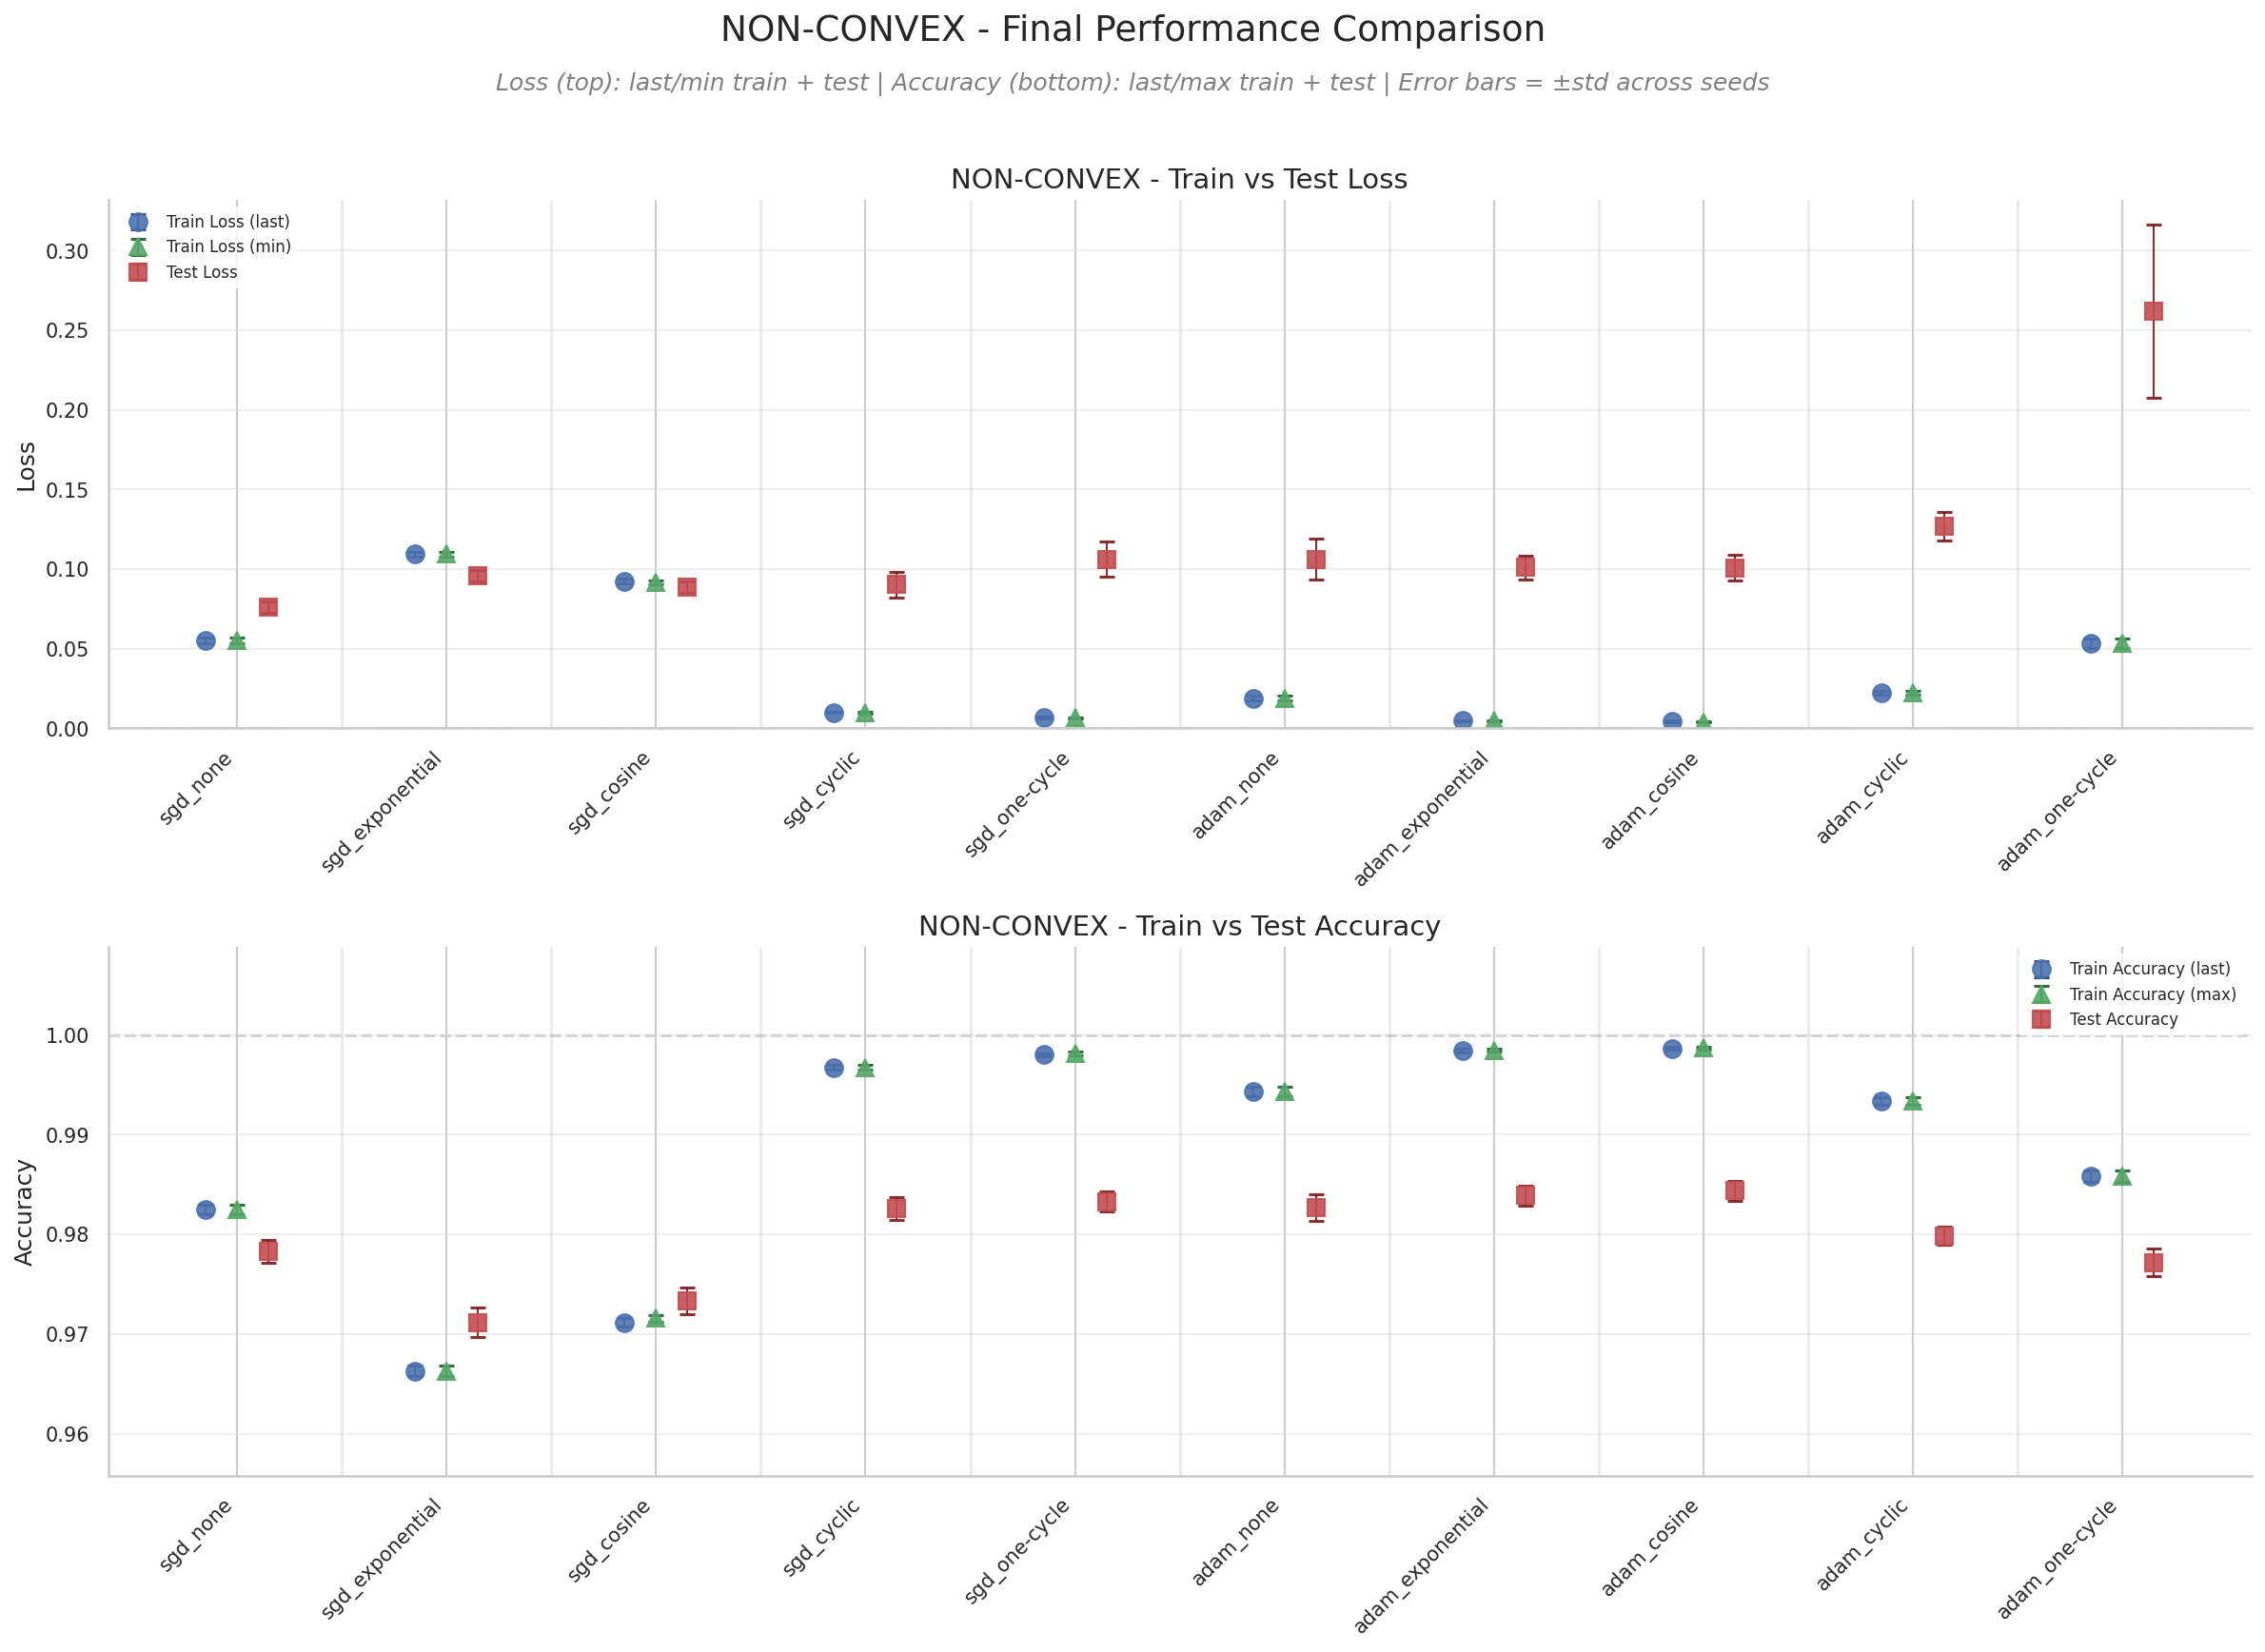

[viz] Saved: ../reports/figures/non-convex_analytical_a_loss_lr_dual.png


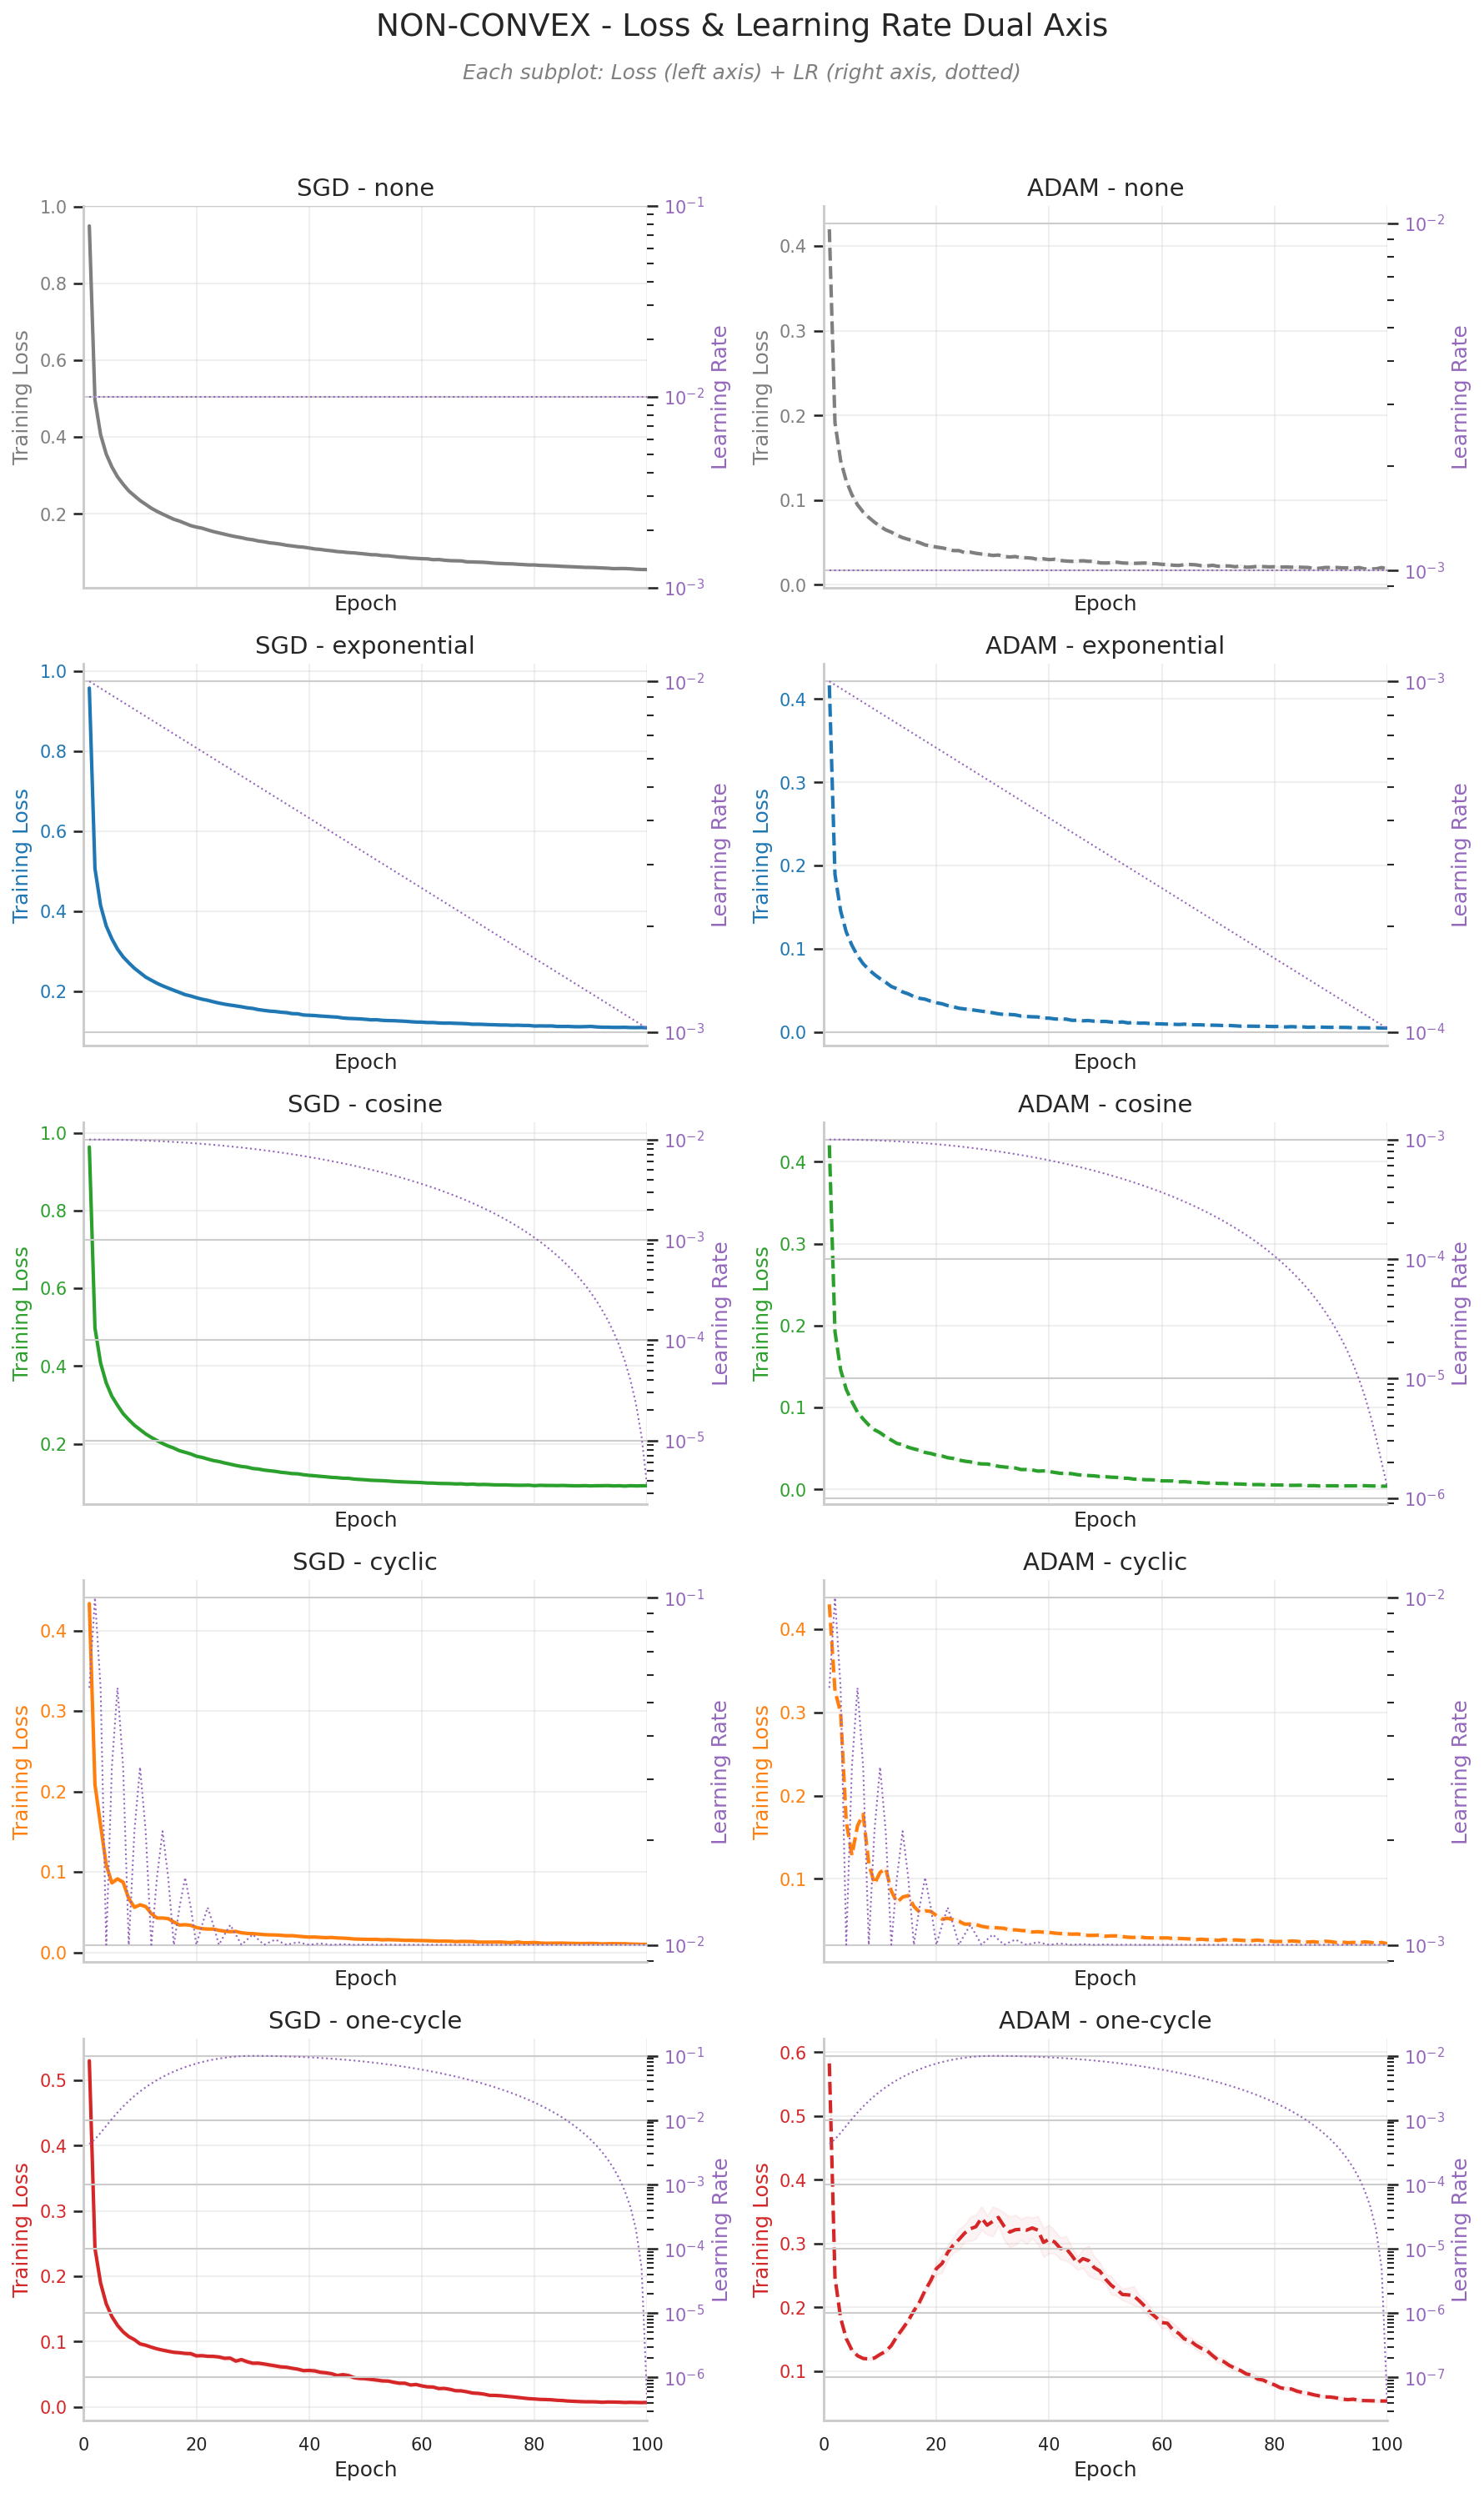

[viz] All plots saved for: non-convex


Saved 5 plot files:
  - ../reports/figures/non-convex_level1_global_comparison.png
  - ../reports/figures/non-convex_level2_by_optimizer.png
  - ../reports/figures/non-convex_level3_seed_variance.png
  - ../reports/figures/non-convex_level4_final_performance.png
  - ../reports/figures/non-convex_analytical_a_loss_lr_dual.png


In [29]:

# Generate all plots for both problem types
for problem_type in ["convex", "non-convex"]:
    print(f"\n{'='*60}")
    print(f"Generating plots for: {problem_type.upper()}")
    print('='*60)
    
    # Get aggregated metrics
    aggregated = convergence_results[problem_type]["aggregated"]
    
    # Get results for this problem type
    results_by_problem = results[problem_type]
    
    # Compute L_star if available (for convex problems)
    L_star_global = convergence_results[problem_type]["L_star"]
    L0_global = convergence_results[problem_type].get("L0")
    e_target_levels = E_TARGET_LEVELS
    print(f"L_star = {L_star_global:.6f}, L0 = {L0_global:.6f}")
    print(f"E_target levels: {e_target_levels}")
    
    # Generate all plots
    saved_files = plot_all(
        results_by_problem=results_by_problem,
        aggregated=aggregated,
        problem_type=problem_type,
        L_star_global=L_star_global,
        L0=L0_global,
        e_target_levels=e_target_levels,
        save_dir=figures_dir,
        show=True,  # Set to True to display plots
    )
    
    print(f"Saved {len(saved_files)} plot files:")
    for f in saved_files:
        print(f"  - {f}")

## 6b. Convergence Velocity (Epochs-to-Target Boxplots)

For each E_target level, visualize the distribution of epochs required
to reach the target loss across all configurations and seeds.

In [30]:
import pandas as pd
import numpy as np
from IPython.display import display

def generate_full_convergence_table(e_target_results_dict, problem_type, max_epochs=100):
    levels = ["E_target_lv1", "E_target_lv2", "E_target_lv3"]
    summary_dfs = []

    for lv in levels:
        if lv not in e_target_results_dict[problem_type]:
            continue
            
        df = e_target_results_dict[problem_type][lv].copy()
        if df.empty: 
            continue

        # 1. Separazione e pulizia dei nomi
        df[['Optimizer', 'Scheduler']] = df['Configuration'].str.split('_', n=1, expand=True)
        df['Optimizer'] = df['Optimizer'].str.upper()
        df['Scheduler'] = df['Scheduler'].str.replace('-', ' ').str.title().replace("None", "Constant LR")

        # 2. FILTRO CRUCIALE: Selezioniamo SOLO le run che convergono (sotto il max_epochs e non NaN)
        is_converged = (df["Epochs_to_Target"] < max_epochs) & (df["Epochs_to_Target"].notna())
        df_converged = df[is_converged]

        # 3. Creazione Pivot Table: passiamo solo l'Optimizer alle colonne.
        # Rimuovendo lo 'Status', eliminiamo il terzo livello dell'intestazione.
        pivot = pd.crosstab(
            index=df_converged['Scheduler'],
            columns=df_converged['Optimizer'],
        )
        
        # 4. Ricostruiamo il MultiIndex con soli 2 livelli: (Livello, Ottimizzatore)
        pivot.columns = pd.MultiIndex.from_tuples([(lv, col) for col in pivot.columns])
        summary_dfs.append(pivot)

    # Unione di tutti i livelli in un'unica tabella
    if summary_dfs:
        # Usiamo un outer join (axis=1) così se uno scheduler non ha MAI converso in nessun livello,
        # Pandas mantiene comunque la riga compilando con 0 grazie a .fillna(0)
        final_summary = pd.concat(summary_dfs, axis=1)
        final_summary = final_summary.fillna(0).astype(int)
        
        print(f"\n[ TABELLA DI CONVERGENZA COMPLETA (SOLO RUN CONVERGENTI): {problem_type.upper()} ]")
        display(final_summary)
        return final_summary
    
for problem_type in ["convex", "non-convex"]:
    generate_full_convergence_table(e_target_results, problem_type, max_epochs=convergence_results[problem_type]["max_epochs"])


[ TABELLA DI CONVERGENZA COMPLETA (SOLO RUN CONVERGENTI): CONVEX ]


E_target_lv1     E_target_lv2     E_target_lv3
                  ADAM SGD         ADAM SGD          SGD
Scheduler                                               
Cyclic               2  10            0  10            3
One Cycle            9  10            4  10            7


[ TABELLA DI CONVERGENZA COMPLETA (SOLO RUN CONVERGENTI): NON-CONVEX ]


E_target_lv1     E_target_lv2     E_target_lv3    
                    ADAM SGD         ADAM SGD         ADAM SGD
Scheduler                                                     
Constant LR           10   0            4   0            0   0
Cosine                10   0           10   0           10   0
Cyclic                10  10            0  10            0   0
Exponential           10   0           10   0           10   0
One Cycle              0  10            0  10            0  10


Generating grouped boxplot for convex - E_target_lv1 (L_target=0.089385)


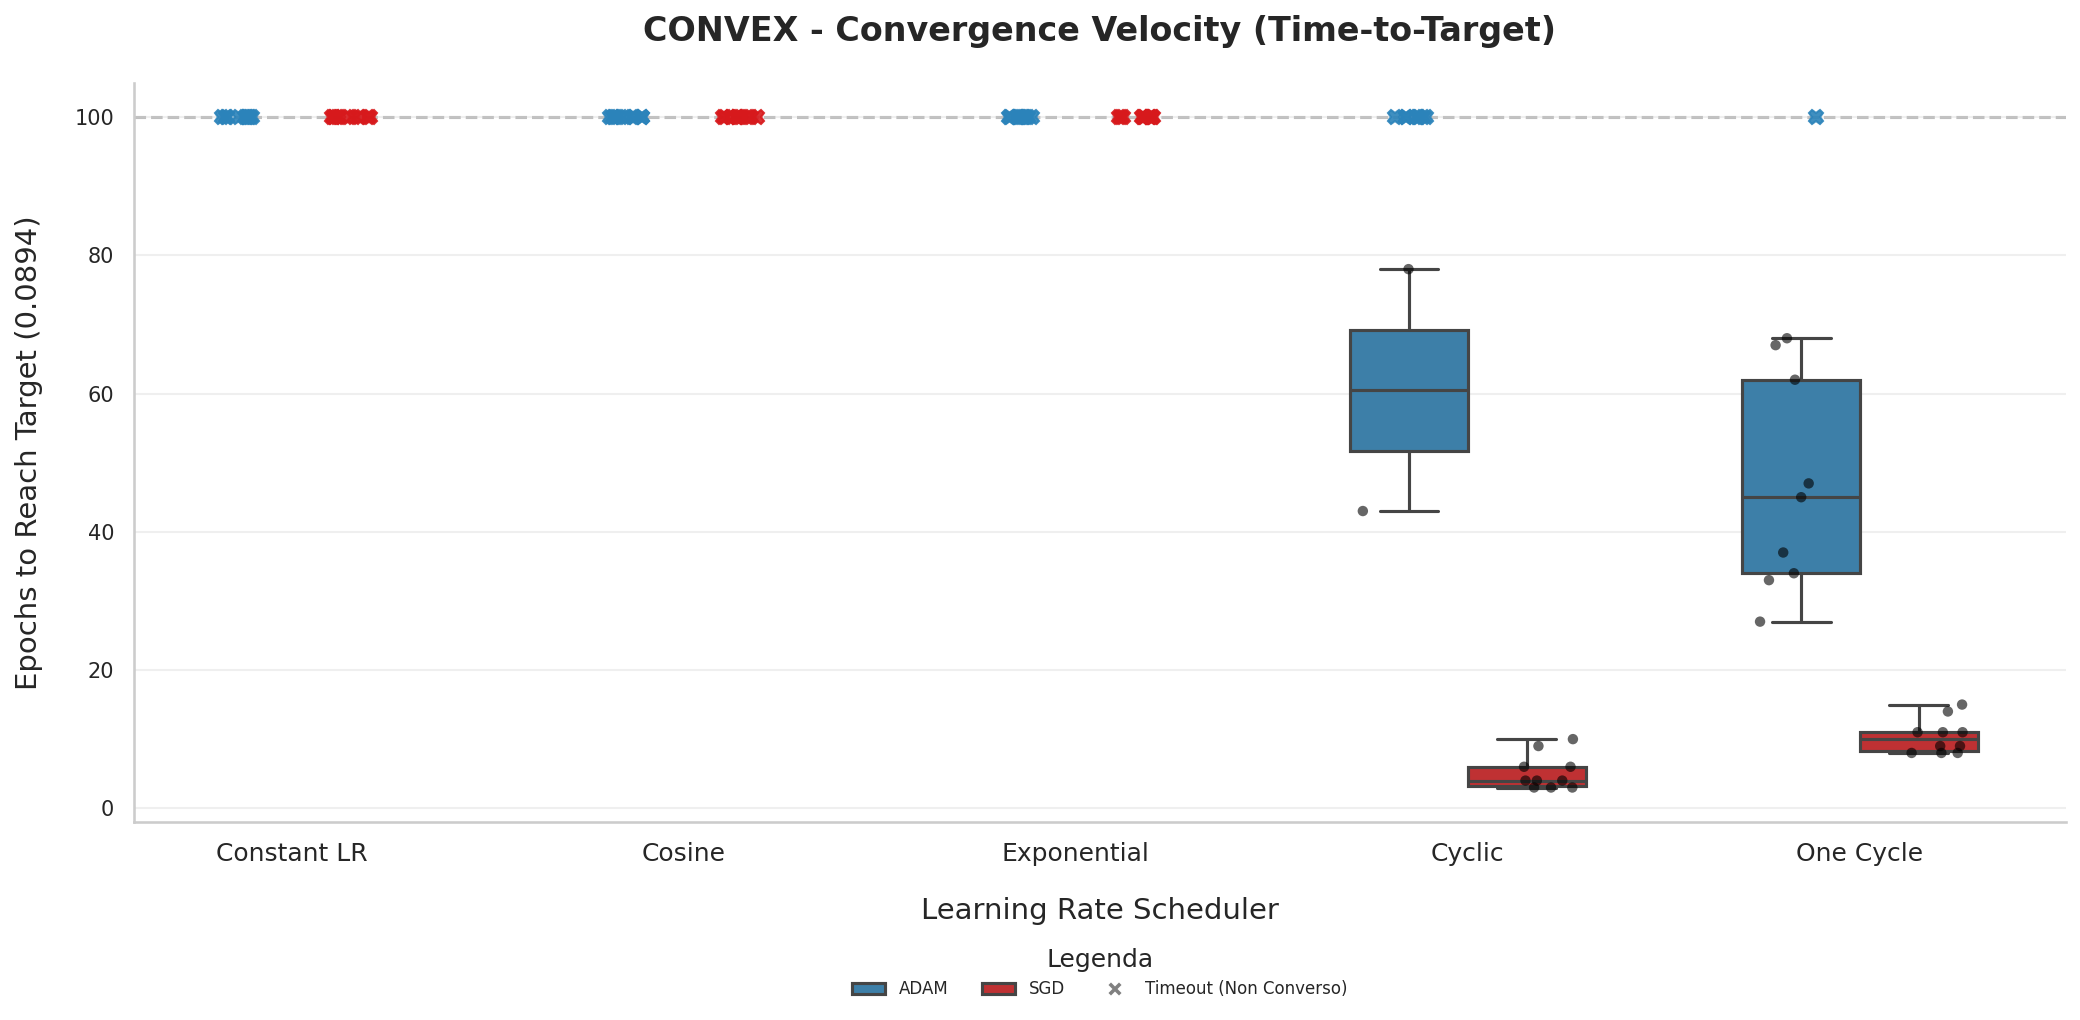


Generating grouped boxplot for convex - E_target_lv2 (L_target=0.067012)


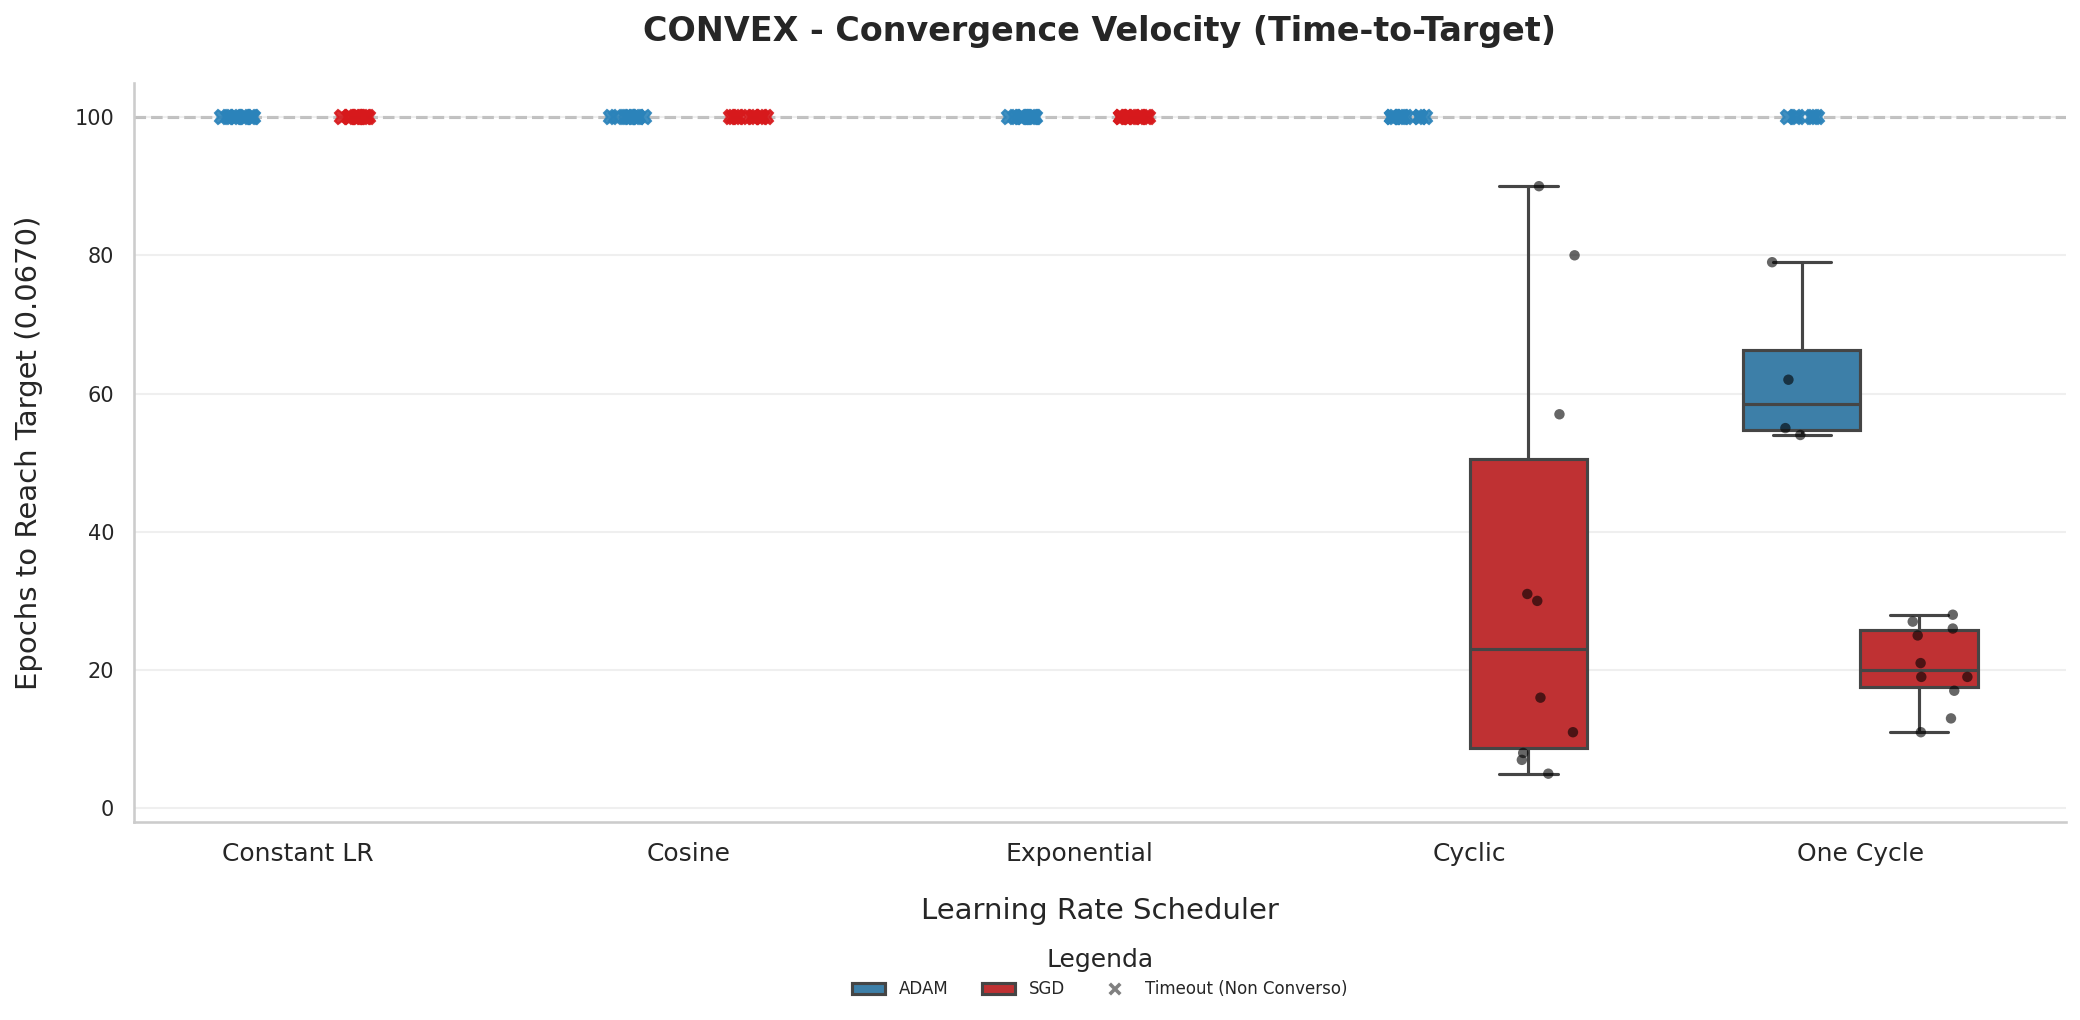


Generating grouped boxplot for convex - E_target_lv3 (L_target=0.053589)


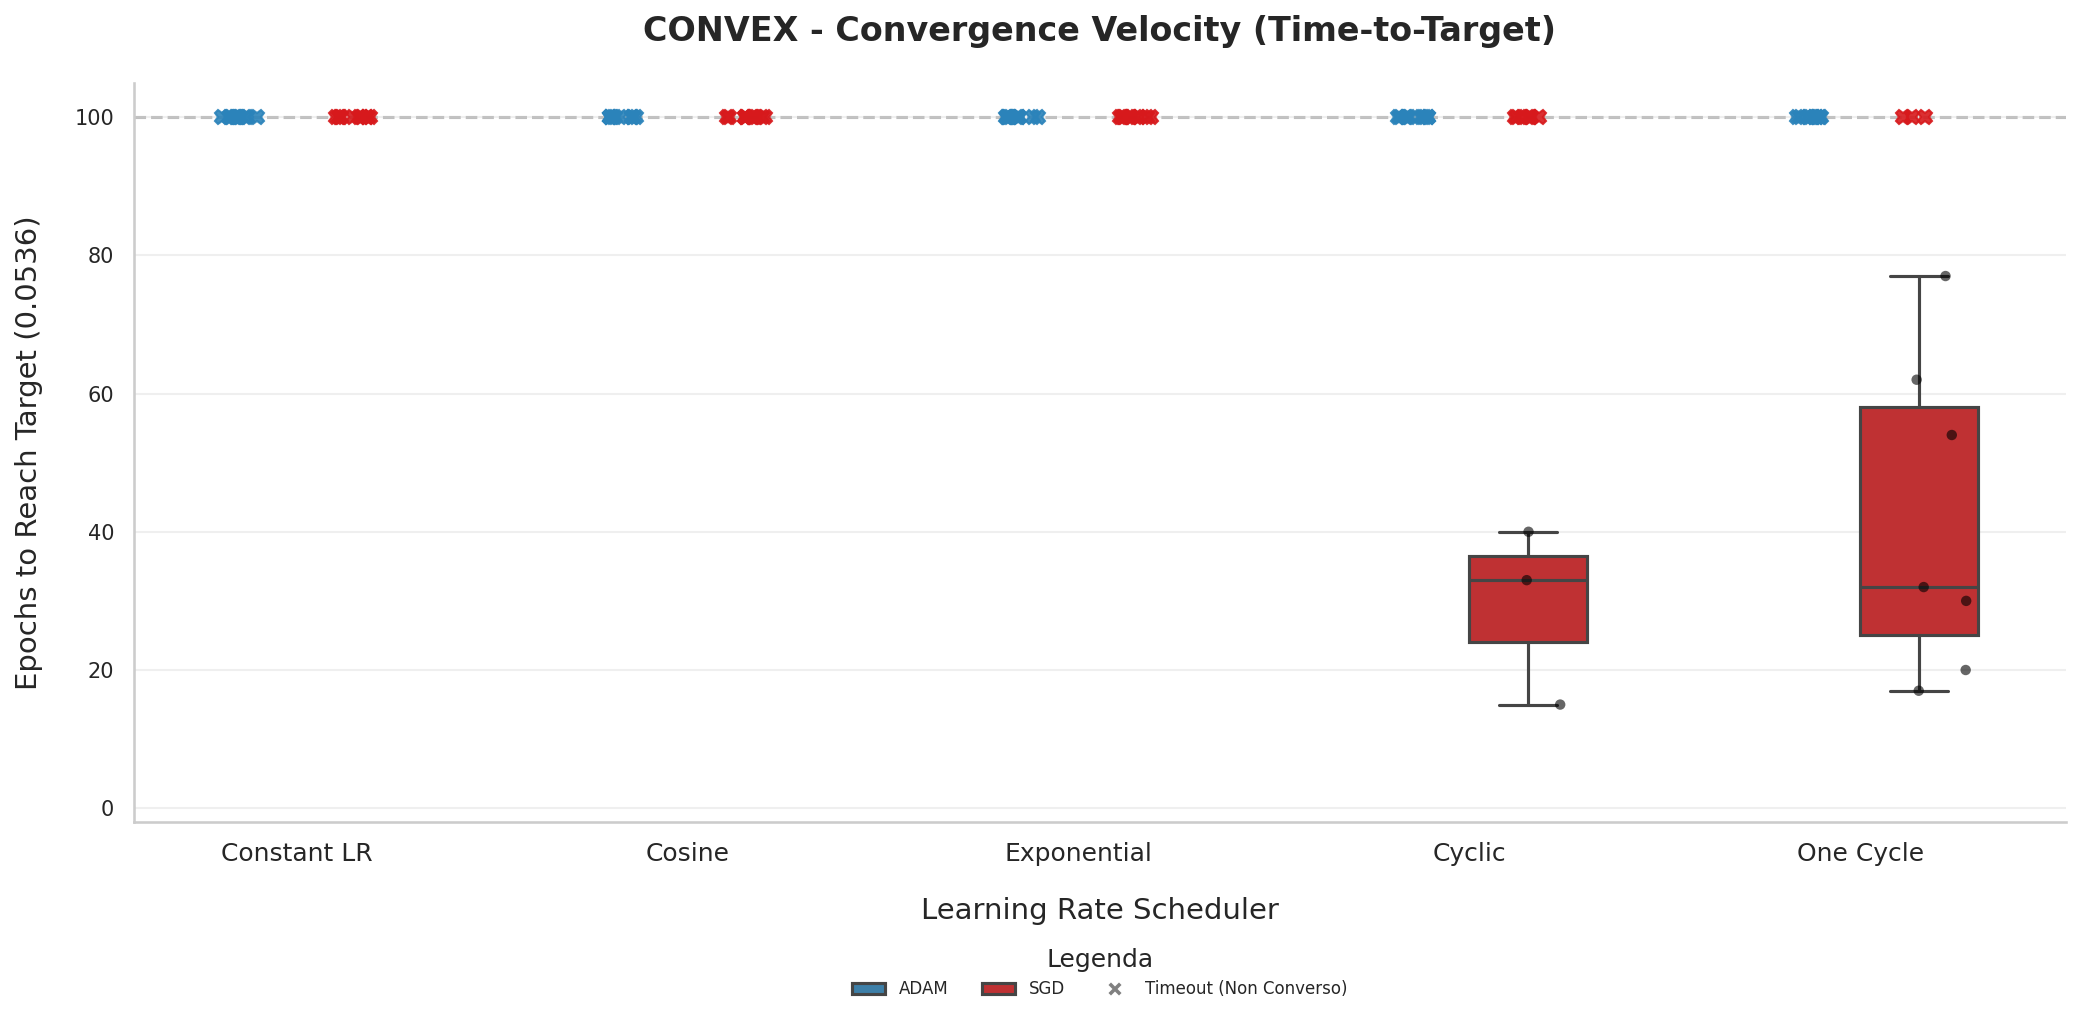


Generating grouped boxplot for non-convex - E_target_lv1 (L_target=0.032154)


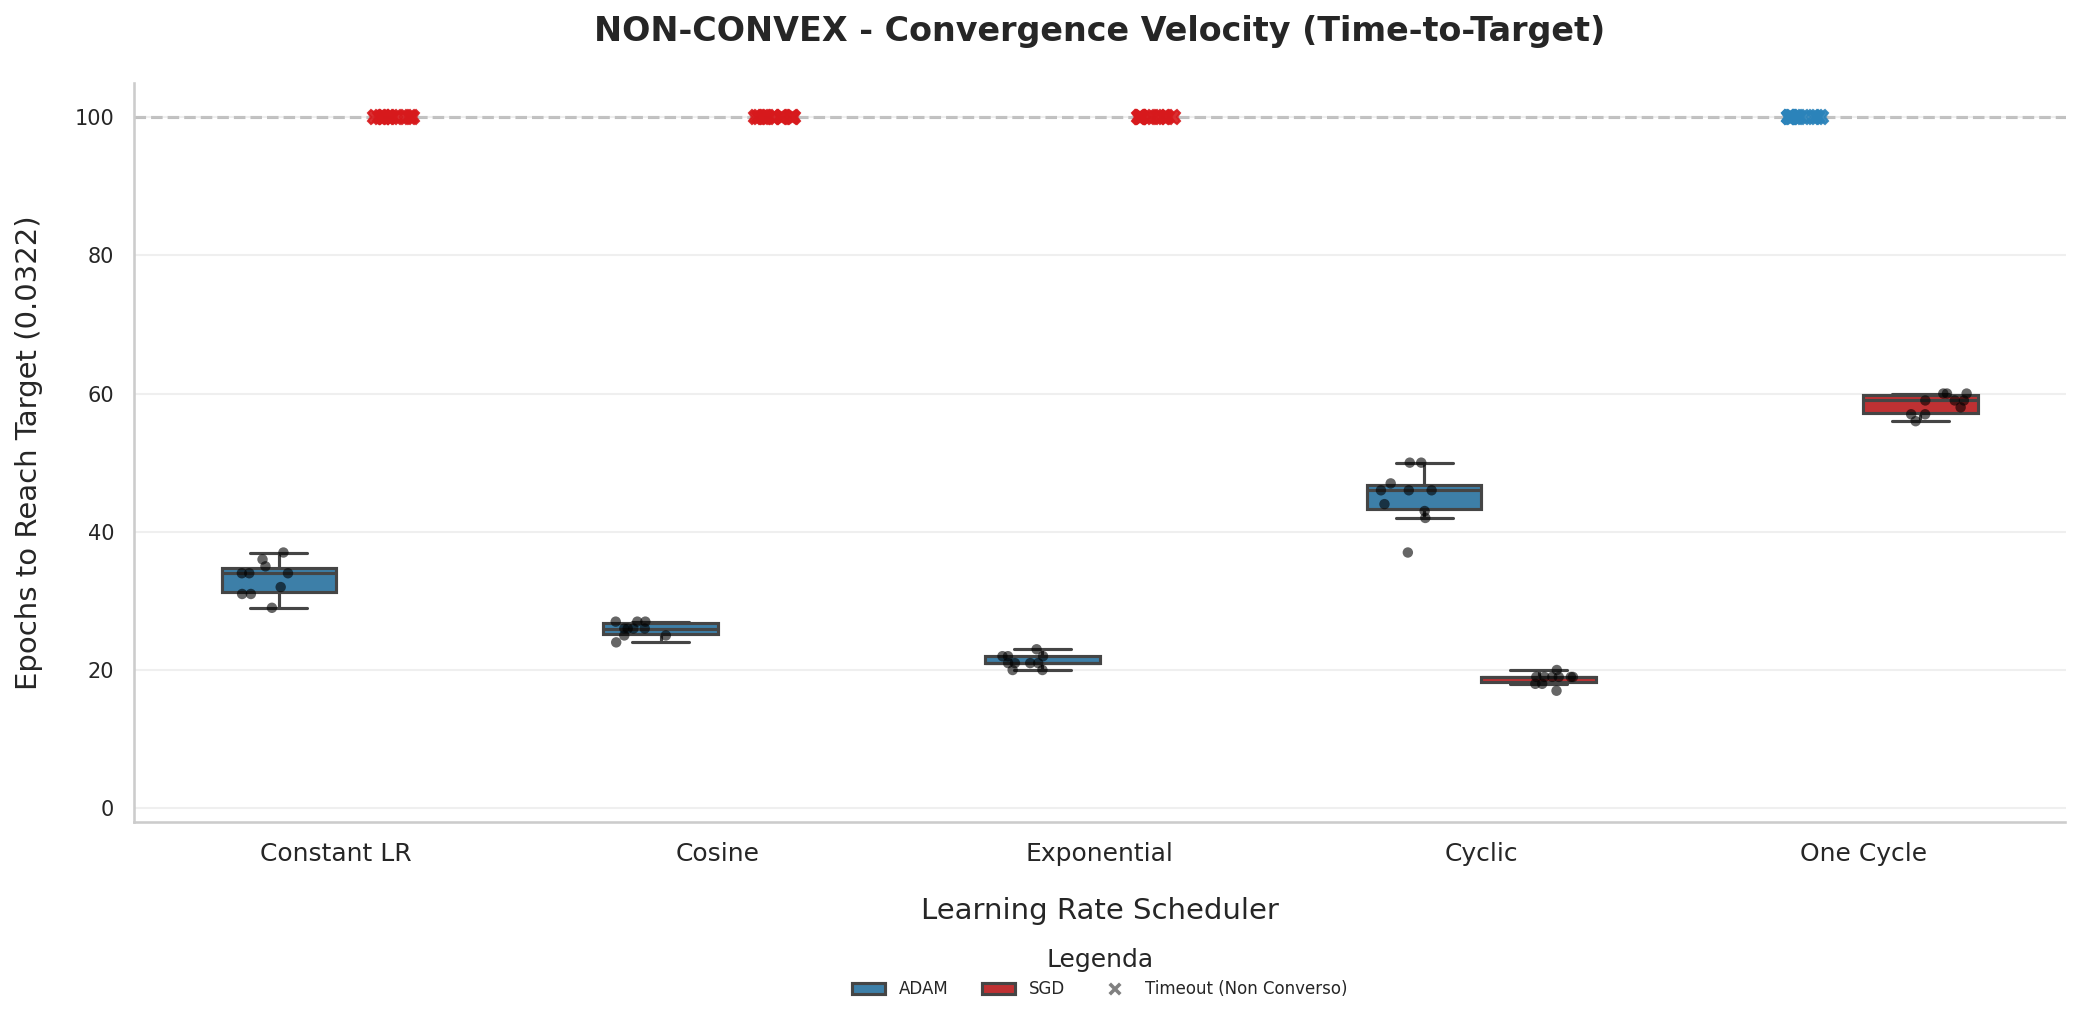


Generating grouped boxplot for non-convex - E_target_lv2 (L_target=0.016943)


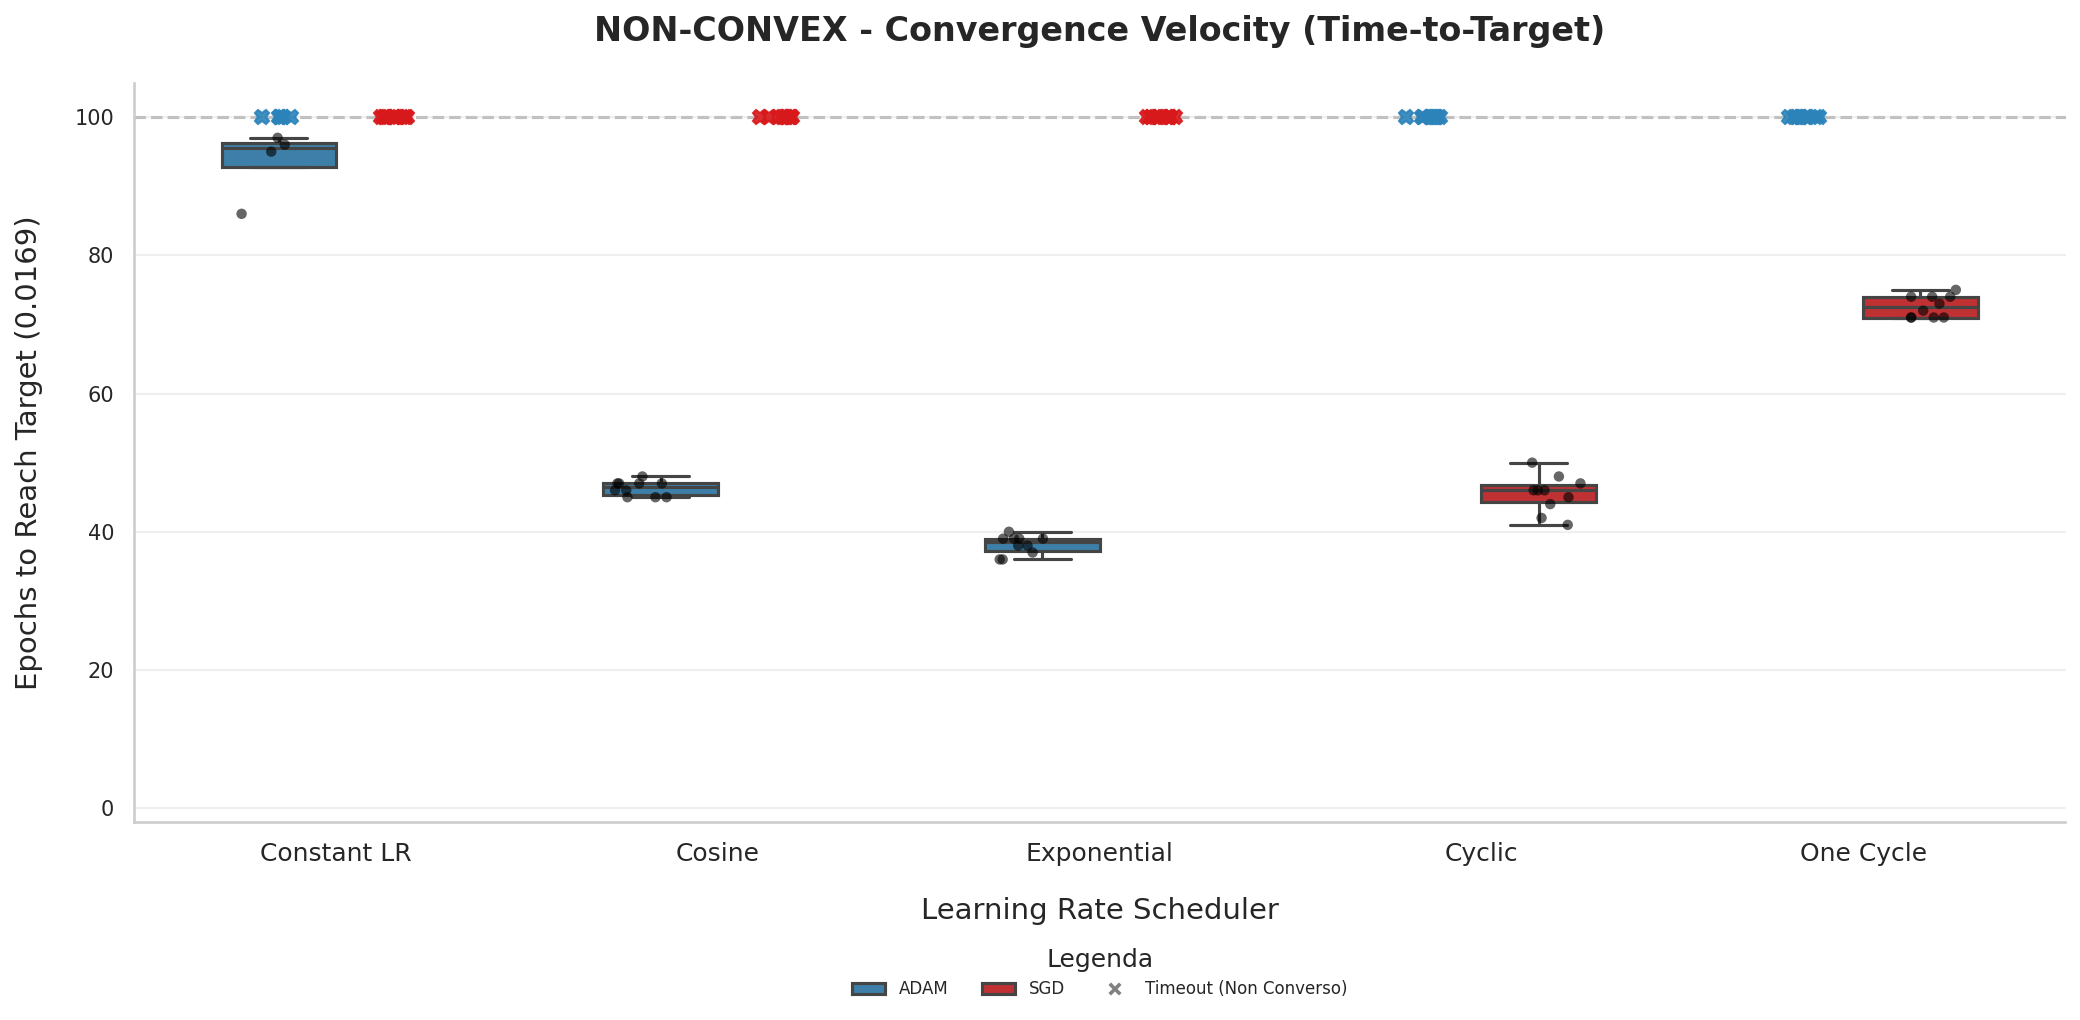


Generating grouped boxplot for non-convex - E_target_lv3 (L_target=0.007817)


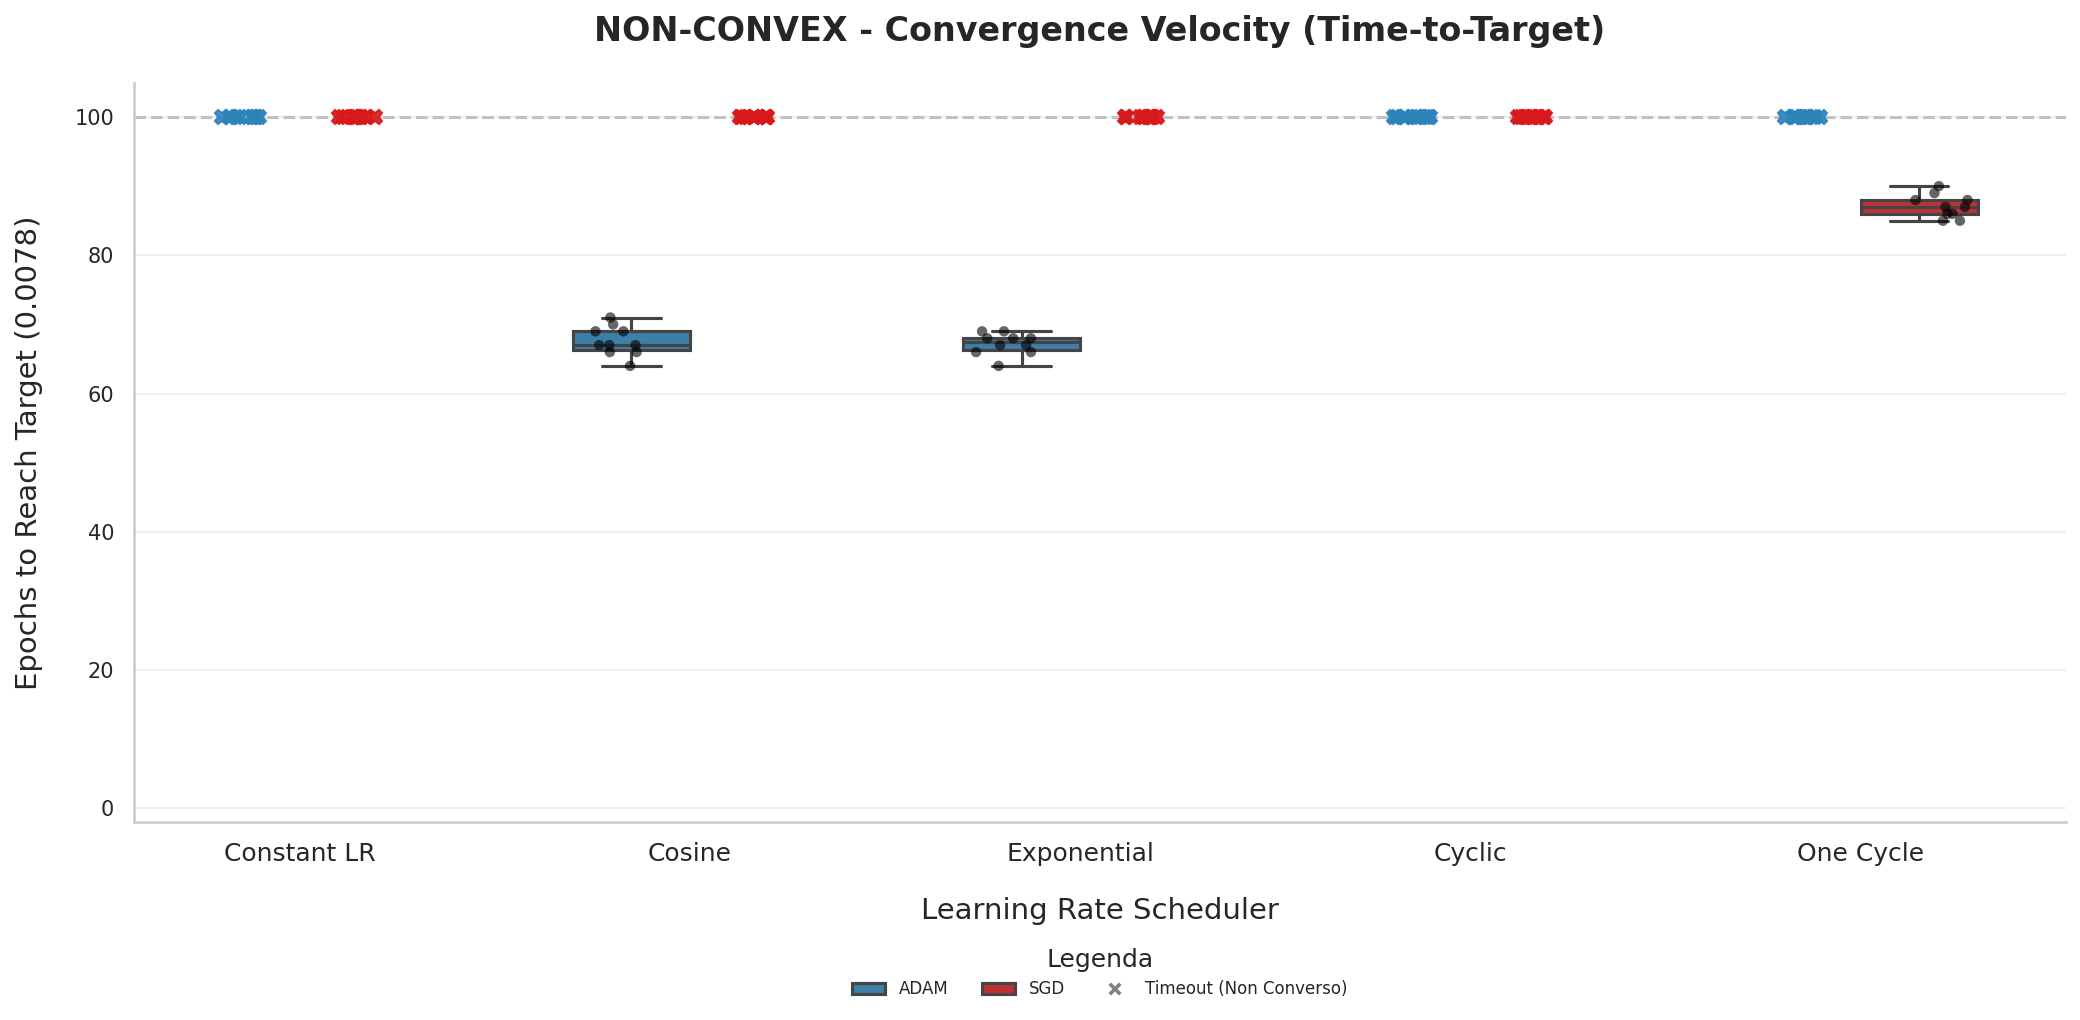

In [31]:
for problem_type in ["convex", "non-convex"]:
    # Scegli i livelli in base al problema (assicurati di usare i dizionari giusti)
    levels = E_TARGET_LEVELS
    
    for level_name, eps in levels.items():
        # 1. Estrai il dataframe e creane una copia per non alterare il dizionario originale
        df = e_target_results[problem_type][level_name].copy()
        
        if df.empty:
            continue
            
        # ─── OPERAZIONI PRELIMINARI SUL DATAFRAME ─────────────────────────
        
        # 2. Dividi "Configuration" sul primo underscore ("_")
        # Esempio: "adam_one-cycle" -> colonna "Optimizer": "adam", colonna "Scheduler": "one-cycle"
        df[['Optimizer', 'Scheduler']] = df['Configuration'].str.split('_', n=1, expand=True)
        
        # 3. Formattazione estetica per il grafico (Opzionale ma molto consigliata)
        df['Optimizer'] = df['Optimizer'].str.upper()  # "sgd" -> "SGD", "adam" -> "ADAM"
        df['Scheduler'] = df['Scheduler'].str.replace('-', ' ').str.title() # "one-cycle" -> "One Cycle"
        df['Scheduler'] = df['Scheduler'].replace("None", "Constant LR")    # Più chiaro di "None"
        
        # ──────────────────────────────────────────────────────────────────
        
        L_target = df["L_target"].iloc[0]
        max_epochs = config.experiments[problem_type].epochs or config.epochs
        save_path = figures_dir / f"{problem_type}_{level_name}_boxplot.png"

        print(f"\nGenerating grouped boxplot for {problem_type} - {level_name} (L_target={L_target:.6f})")

        # 4. Chiama la NUOVA funzione di plotting
        fig = plot_convergence_boxplot(
            df_convergence=df, 
            problem_type=problem_type, 
            L_target=L_target, 
            max_epochs=max_epochs,
            save_path=save_path,
            show=True,
        )

## 6c. Heatmap of Convergence Metrics


Heatmap for: CONVEX


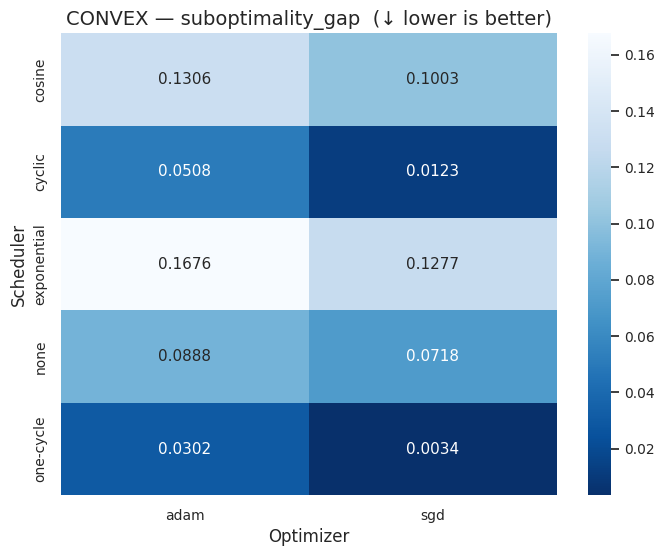

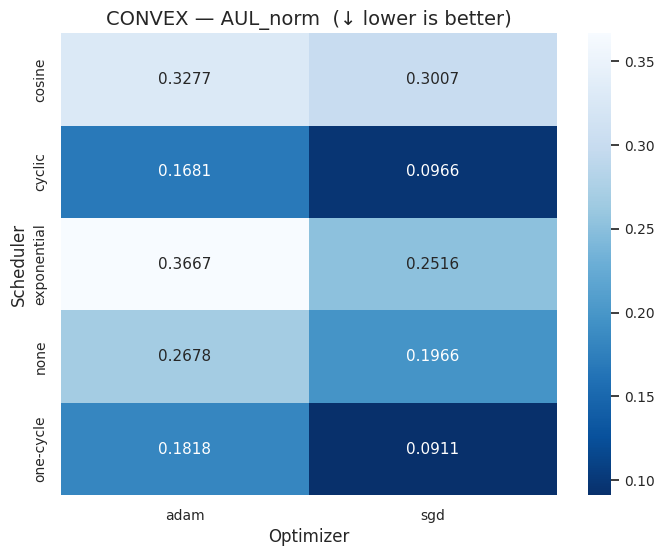

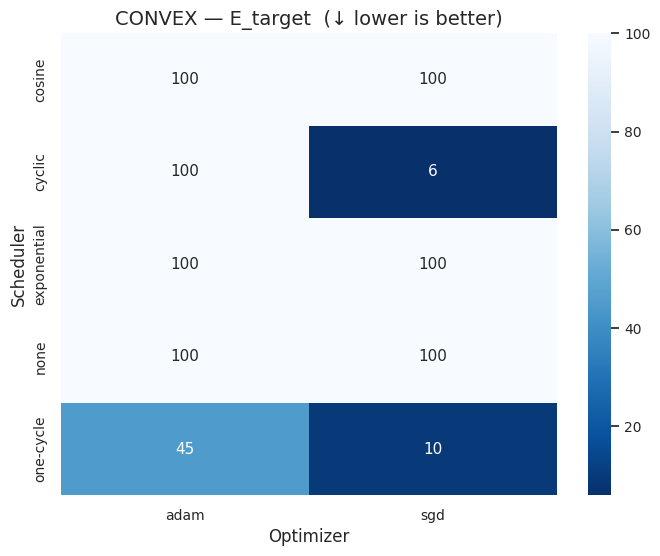

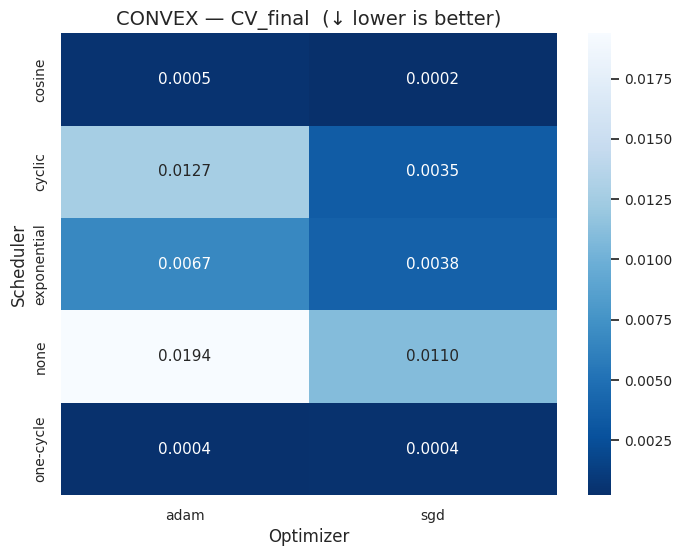

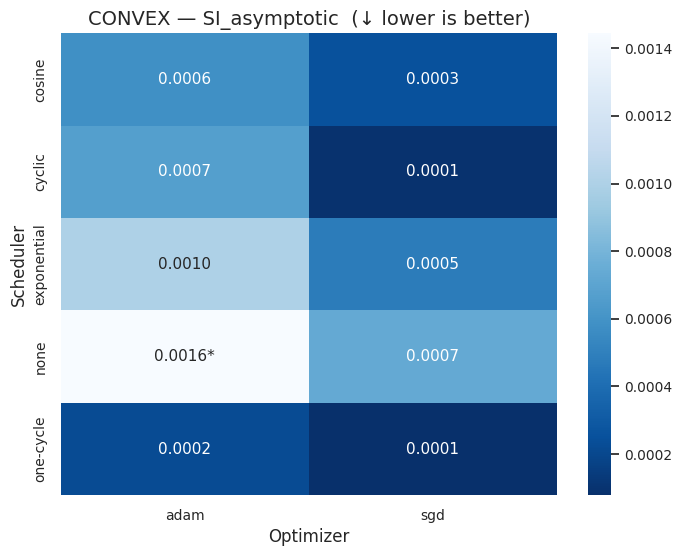

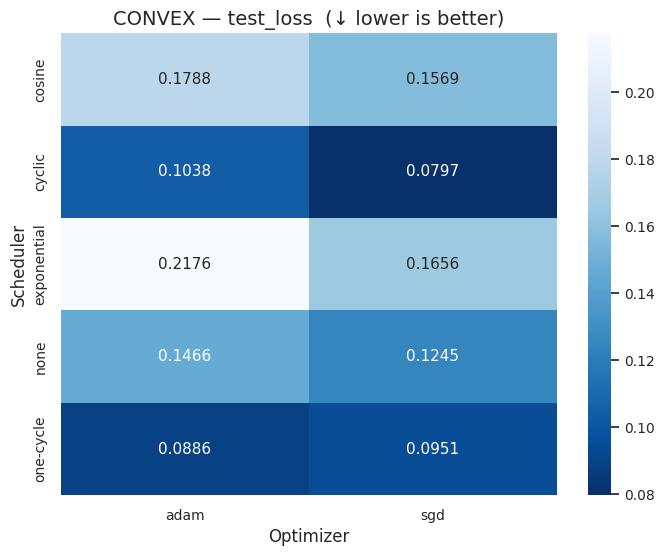

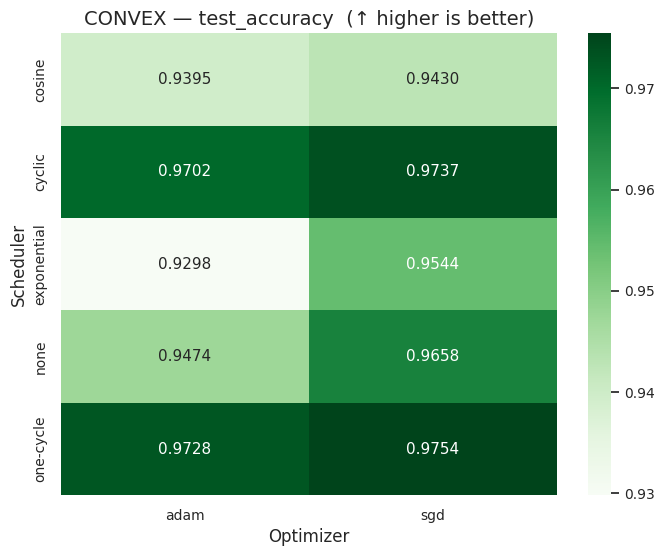


Heatmap for: NON-CONVEX


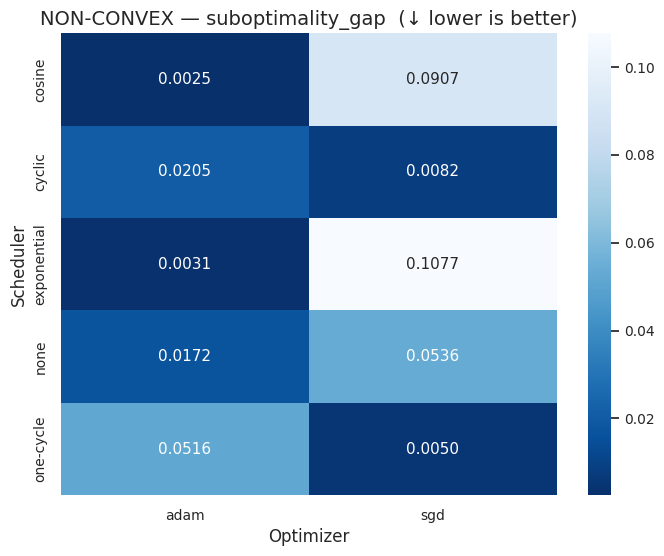

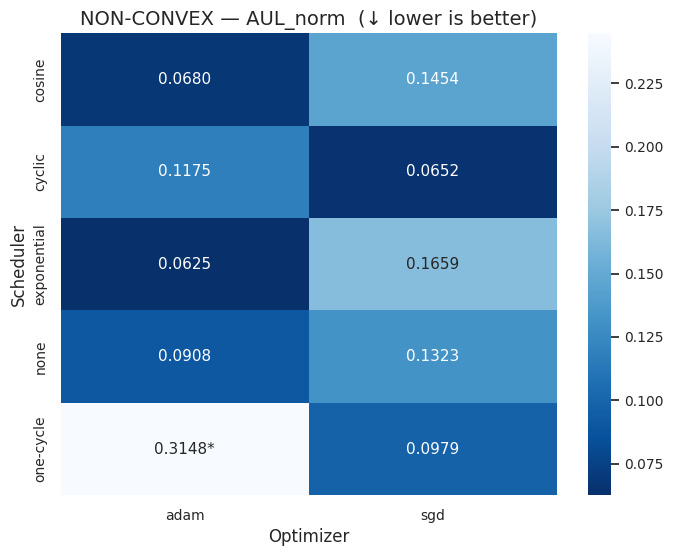

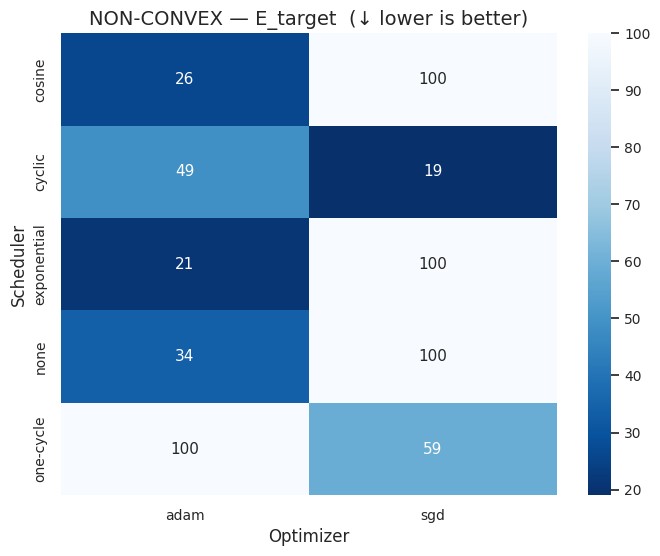

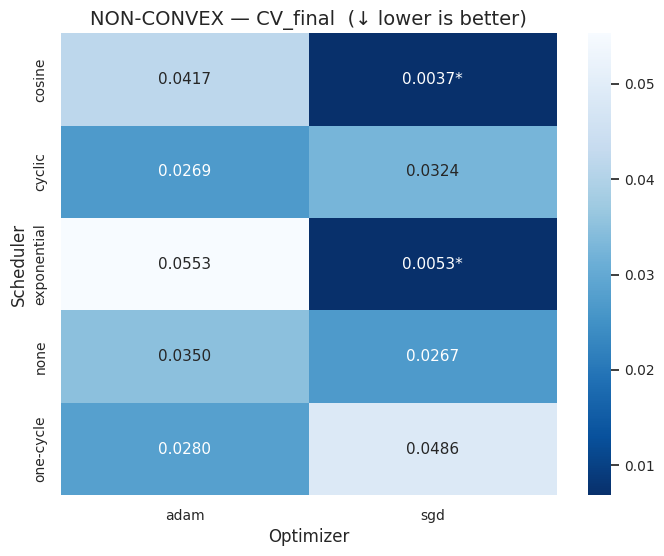

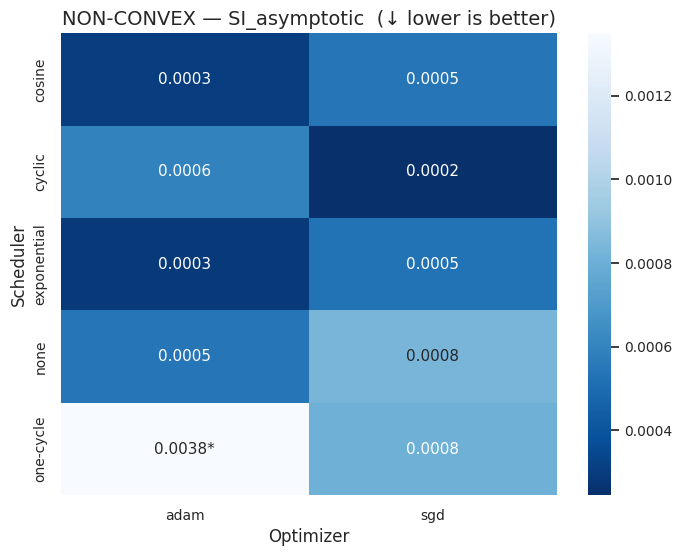

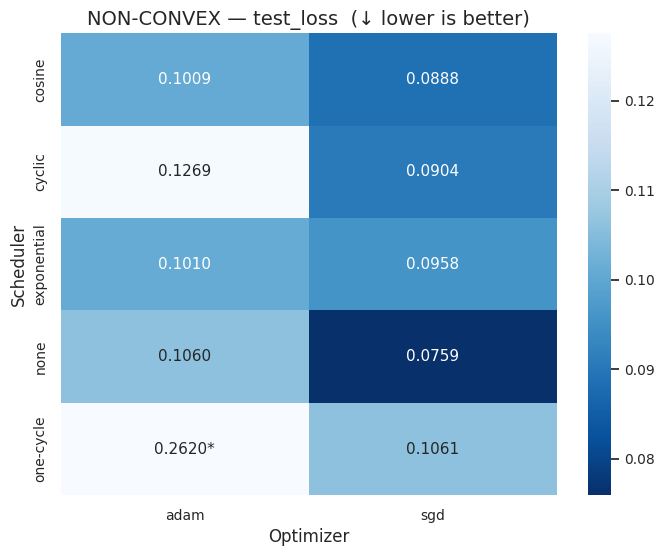

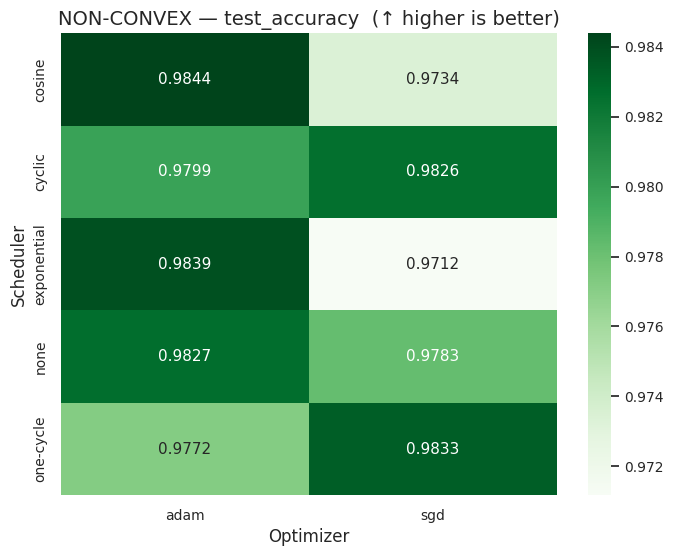

In [32]:
# Analytical B: Heatmap (returns list of saved files)
from stoc_opt_scheduler_comparison.visualization.plots import plot_scheduler_optimizer_heatmap

for problem_type in ["convex", "non-convex"]:

    print(f"\n{'='*60}")
    print(f"Heatmap for: {problem_type.upper()}")
    print('='*60)

    save_path = figures_dir / f"{problem_type}_analytical_b_heatmap.png"

    df_agg_met = convergence_results[problem_type]["aggregated_curve_metrics"]


    plot_scheduler_optimizer_heatmap(
        df_agg_met, problem_type,
        metrics=["suboptimality_gap", "AUL_norm", "E_target","CV_final", "SI_asymptotic", "test_loss", "test_accuracy"],
        save_path=save_path,
        show=True
    )

## 7. Summary & Key Findings

### Best Configuration per Problem Type

In [26]:
for problem_type in ["convex", "non-convex"]:
    agg = convergence_results[problem_type]["aggregated"]
    
    # Find best by accuracy
    best_acc_key = max(agg.keys(), key=lambda k: agg[k].get("test_accuracy_mean", 0))
    best_acc = agg[best_acc_key]
    
    # Find fastest convergence (lowest EtT)
    best_ett_key = min(agg.keys(), key=lambda k: agg[k].get("EtT_mean", float("inf")))
    best_ett = agg[best_ett_key]
    
    # Find most stable (lowest CV)
    best_stable_key = min(agg.keys(), key=lambda k: agg[k].get("CV_final_mean", float("inf")))
    best_stable = agg[best_stable_key]
    
    print(f"\n{'='*60}")
    print(f"{problem_type.upper()} - Summary")
    print(f"{'='*60}")
    print(f"Best accuracy:     {best_acc['optimizer']} + {best_acc['scheduler']} → {best_acc['test_accuracy_mean']:.4f} ± {best_acc['test_accuracy_std']:.4f}")
    print(f"Fastest converge:  {best_ett['optimizer']} + {best_ett['scheduler']} → EtT={best_ett['EtT_mean']:.1f} ± {best_ett['EtT_std']:.1f}")
    print(f"Most stable:       {best_stable['optimizer']} + {best_stable['scheduler']} → CV={best_stable['CV_final_mean']:.6f}")


CONVEX - Summary
Best accuracy:     sgd + one-cycle → 0.9754 ± 0.0123
Fastest converge:  sgd + cyclic → EtT=6.1 ± 6.4
Most stable:       sgd + cosine → CV=0.000221

NON-CONVEX - Summary
Best accuracy:     adam + cosine → 0.9844 ± 0.0010
Fastest converge:  sgd + cyclic → EtT=12.1 ± 0.3
Most stable:       sgd + cosine → CV=0.011332


## 8. Save and Load Results

### Save Convergence metrics

In [37]:
# Export results to CSV for further analysis
for problem_type in ["convex", "non-convex"]:
    metrics_list = convergence_results[problem_type]["per_run"]
    df = pd.DataFrame(metrics_list)
    csv_path = results_dir / f"{problem_type}_metrics.csv"
    df.to_csv(csv_path, index=False)
    print(f"Saved: {csv_path} ({len(df)} rows)")

Saved: ../results/convex_metrics.csv (19 rows)
Saved: ../results/non-convex_metrics.csv (19 rows)


### Save results dict

In [52]:
def save_results(results: dict, save_dir: str | Path = Path("../results"), filename: str = "results.pkl") -> Path:
    """
    Serialize results dict to disk using pickle (no compression, no conversion).

    Args:
        results:  The dict to save.
        save_dir: Directory where the file will be written (created if missing).
        filename: Output filename (default: results.pkl).

    Returns:
        Path of the saved file.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    output_path = save_dir / filename
    with open(output_path, "wb") as f:
        pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)
    return output_path

# Salvataggio
save_results(results, save_dir=results_dir, filename="results_v4_conv-50.pkl")


PosixPath('../results/results_v4_conv-50.pkl')

### Load results dict

In [5]:
def load_results(save_dir: str | Path = Path("../results"), filename: str = "results.pkl") -> dict:
    """
    Load results dict from disk.

    Args:
        save_dir: Directory containing the file.
        filename: File to load (default: results.pkl).

    Returns:
        The deserialized dict.

    Raises:
        FileNotFoundError: If the file does not exist.
    """
    path = Path(save_dir) / filename
    if not path.exists():
        raise FileNotFoundError(f"Results file not found: {path}")
    with open(path, "rb") as f:
        return pickle.load(f)
    

# Caricamento
results = load_results(save_dir=results_dir, filename="results_v4.pkl")

## Load Result from MlFLow

In [6]:
results = load_results_from_mlflow(
    experiment_name="scheduler_comparison_v3",
    tracking_uri="../mlruns",  # o URI remoto
)

/home/narto/Documents/uni_projects/MOS/stoc-opt_scheduler_comparison/.venv/lib/python3.10/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
